# Section 1: Importing Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import pickle
import json
import os
from datetime import datetime
from pathlib import Path

# Data preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Feature selection
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV

# Machine Learning Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import explained_variance_score, max_error, mean_absolute_percentage_error

# Statistical analysis
import scipy.stats as stats
from scipy.stats import shapiro, anderson

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


# Section 2: Data Loading

In [2]:
# Define dataset path
dataset_path = "/kaggle/input/bus-business-income-data/sri_lankan_bus_business_dataset_40000.csv"

# Load the dataset
print("Loading dataset...")
try:
    df = pd.read_csv(dataset_path)
    print(f"✓ Dataset loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"Number of records: {df.shape[0]}")
    print(f"Number of features: {df.shape[1]}")
except FileNotFoundError:
    print(f"✗ File not found at {dataset_path}")
    # Create sample data for demonstration
    print("Creating sample data for demonstration...")
    np.random.seed(42)
    n_samples = 1000
    df = pd.DataFrame({
        'date': pd.date_range('2024-01-01', periods=n_samples, freq='D'),
        'route_1_distance': np.random.randint(40, 300, n_samples),
        'route_2_distance': np.random.randint(40, 300, n_samples),
        'route_3_distance': np.random.randint(40, 300, n_samples),
        'daily_collection': np.random.randint(50000, 500000, n_samples),
        'trips_count': np.random.randint(1, 4, n_samples),
        'fuel_cost_per_l': np.random.uniform(320, 380, n_samples),
        'maintenance_cost': np.random.randint(400, 850, n_samples),
        'driver_salary': np.random.randint(1800, 2400, n_samples),
        'conductor_salary': np.random.randint(1300, 1900, n_samples),
        'backup_fuel_cost': np.random.randint(30000, 170000, n_samples),
        'deadweight_factor': np.random.uniform(0, 0.5, n_samples),
        'weather_condition': np.random.choice(['Sunny', 'Rainy', 'Cloudy'], n_samples),
        'day_of_week': np.random.randint(0, 7, n_samples),
        'month': np.random.randint(1, 13, n_samples),
        'holiday_flag': np.random.randint(0, 2, n_samples),
        'festival_season': np.random.randint(0, 2, n_samples),
        'monsoon_season': np.random.randint(0, 2, n_samples),
        'lkr_to_usd_rate': np.random.uniform(320, 330, n_samples),
        'lkr_to_inr_rate': np.random.uniform(2.6, 2.8, n_samples),
        'actual_profit': np.random.randint(-500000, 200000, n_samples),
        'best_route_sequence': np.random.choice(['1-2-3', '2-1-3', '3-1-2', '1-3-2'], n_samples),
        'route_variance': np.random.uniform(0, 120, n_samples),
        'total_distance': np.random.randint(120, 900, n_samples),
        'fuel_efficiency': np.random.uniform(3.0, 4.0, n_samples),
        'bus_age_years': np.random.randint(1, 15, n_samples)
    })

# Display first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Display basic information
print("\nDataset Information:")
print(df.info())

# Display column names
print("\nColumn names:")
print(list(df.columns))

Loading dataset...
✓ Dataset loaded successfully!
Dataset shape: (40000, 26)
Number of records: 40000
Number of features: 26

First 5 rows of the dataset:
         date  route_1_distance  route_2_distance  route_3_distance  daily_collection  trips_count  fuel_cost_per_l  maintenance_cost  driver_salary  conductor_salary  backup_fuel_cost  deadweight_factor weather_condition  day_of_week  month  holiday_flag  festival_season  monsoon_season  lkr_to_usd_rate  lkr_to_inr_rate  actual_profit best_route_sequence  route_variance  total_distance  fuel_efficiency  bus_age_years
0  2024-01-01                80               150                40             97832            2           325.09               802           2148              1767             61441               0.08             Sunny            0      1             0                0               0       322.494276         2.644203        -214092               2-1-3       45.460606             270              3.5             13
1

# Section 3: 1st Data Preprocessing

In [3]:
print("="*80)
print("SECTION 3: INITIAL DATA PREPROCESSING")
print("="*80)

# 1. Check for missing values
print("\n1. Checking for missing values:")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})
print(missing_df[missing_df['Missing Values'] > 0])

if missing_df['Missing Values'].sum() == 0:
    print("✓ No missing values found!")
else:
    print("\nHandling missing values...")
    # Fill numerical columns with median
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    
    # Fill categorical columns with mode
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
    
    print("✓ Missing values handled!")

# 2. Check for duplicates
print("\n2. Checking for duplicates:")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✓ Removed {duplicates} duplicate rows")
else:
    print("✓ No duplicates found!")

# 3. Convert date column to datetime and extract features
print("\n3. Processing date column...")
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month_from_date'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['day_of_year'] = df['date'].dt.dayofyear
    df['week_of_year'] = df['date'].dt.isocalendar().week
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x in [5, 6] else 0)
    print("✓ Date features extracted!")
else:
    print("✗ 'date' column not found!")

# 4. Check data types
print("\n4. Data types:")
print(df.dtypes)

# 5. Check for outliers using IQR method
print("\n5. Checking for outliers in numerical columns...")
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'actual_profit' in numerical_cols:
    numerical_cols.remove('actual_profit')  # Remove target variable

outliers_info = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outliers_percentage = (outliers / len(df)) * 100
    outliers_info[col] = {
        'outliers': outliers,
        'percentage': outliers_percentage,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }

# Display columns with significant outliers (>5%)
print("\nColumns with significant outliers (>5%):")
for col, info in outliers_info.items():
    if info['percentage'] > 5:
        print(f"{col}: {info['outliers']} outliers ({info['percentage']:.2f}%)")

# 6. Handle extreme outliers (optional - can be adjusted)
print("\n6. Handling extreme outliers...")
for col in ['daily_collection', 'backup_fuel_cost', 'actual_profit']:
    if col in df.columns:
        # Cap outliers at 99th percentile
        upper_limit = df[col].quantile(0.99)
        lower_limit = df[col].quantile(0.01)
        df[col] = np.where(df[col] > upper_limit, upper_limit, 
                          np.where(df[col] < lower_limit, lower_limit, df[col]))
        print(f"✓ Capped outliers in {col}")

# 7. Verify preprocessing
print("\n7. Final dataset shape after preprocessing:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n✓ Initial preprocessing completed!")

SECTION 3: INITIAL DATA PREPROCESSING

1. Checking for missing values:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []
✓ No missing values found!

2. Checking for duplicates:
Number of duplicate rows: 0
✓ No duplicates found!

3. Processing date column...
✓ Date features extracted!

4. Data types:
date                   datetime64[ns]
route_1_distance                int64
route_2_distance                int64
route_3_distance                int64
daily_collection                int64
trips_count                     int64
fuel_cost_per_l               float64
maintenance_cost                int64
driver_salary                   int64
conductor_salary                int64
backup_fuel_cost                int64
deadweight_factor             float64
weather_condition              object
day_of_week                     int64
month                           int64
holiday_flag                    int64
festival_season                 int64
monsoon_season                  int

# Section 4: Exploratory Data Analysis (EDA)

SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)

1. Basic Statistics:
                                date  route_1_distance  route_2_distance  route_3_distance  daily_collection   trips_count  fuel_cost_per_l  maintenance_cost  driver_salary  conductor_salary  backup_fuel_cost  deadweight_factor   day_of_week         month  holiday_flag  festival_season  monsoon_season  lkr_to_usd_rate  lkr_to_inr_rate  actual_profit  route_variance  total_distance  fuel_efficiency  bus_age_years          year  month_from_date           day   day_of_year  week_of_year    is_weekend
count                          40000      40000.000000      40000.000000      40000.000000      40000.000000  40000.000000     40000.000000      40000.000000   40000.000000       40000.00000      40000.000000       40000.000000  40000.000000  40000.000000  40000.000000     40000.000000    40000.000000     40000.000000     40000.000000   40000.000000    40000.000000    40000.000000          40000.0   40000.000000  40000.000000   

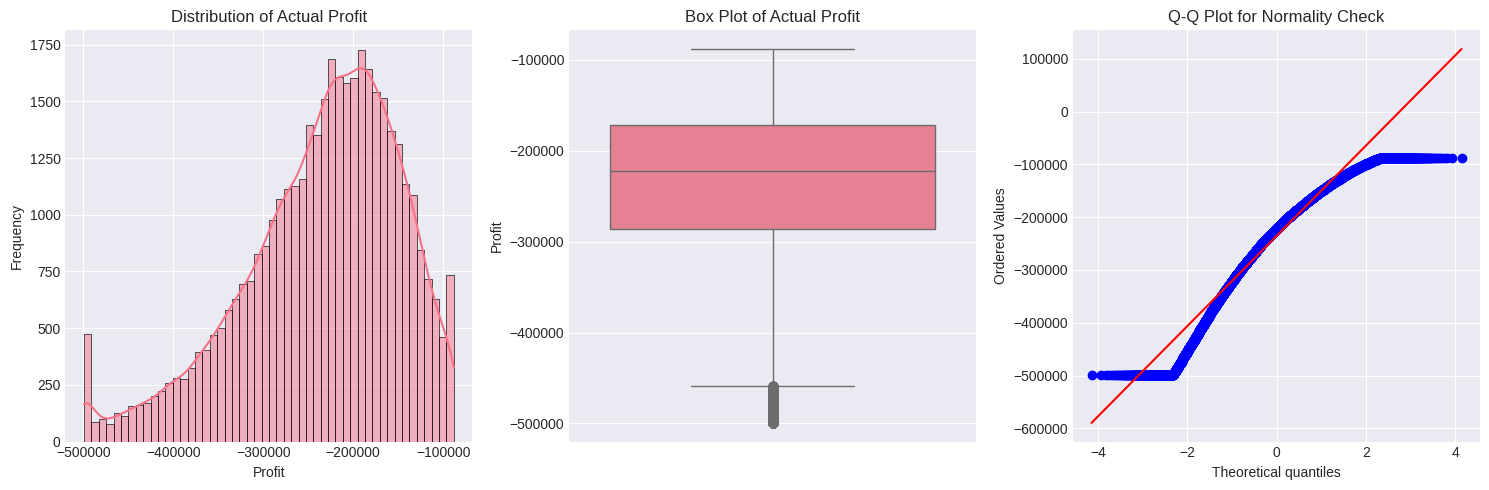


Normality Tests for actual_profit:
Shapiro-Wilk Test: statistic=0.9548, p-value=0.0000
  → Data does not appear to be normally distributed (p ≤ 0.05)
Anderson-Darling Test: statistic=388.7280
  → At 15.0% significance level, data does not look normal (stat ≥ 0.576)
  → At 10.0% significance level, data does not look normal (stat ≥ 0.656)
  → At 5.0% significance level, data does not look normal (stat ≥ 0.787)
  → At 2.5% significance level, data does not look normal (stat ≥ 0.918)
  → At 1.0% significance level, data does not look normal (stat ≥ 1.092)

3. Correlation Analysis:


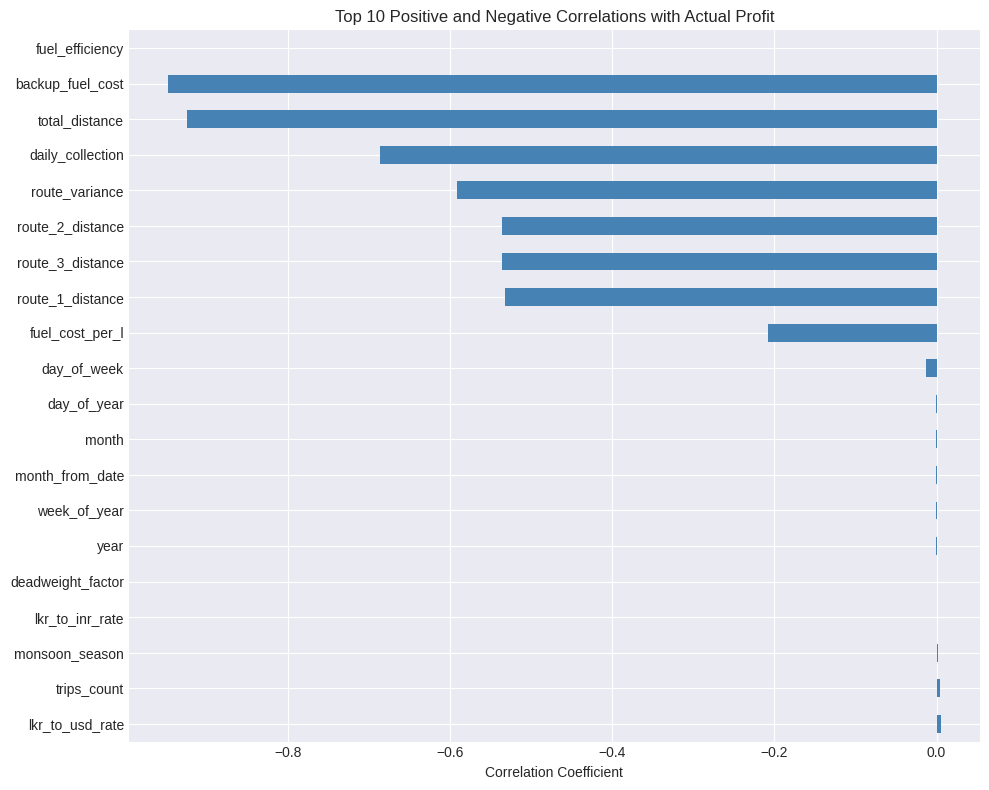


Top 10 positive correlations:
lkr_to_usd_rate      0.005858
trips_count          0.004344
monsoon_season       0.001492
lkr_to_inr_rate      0.000863
deadweight_factor    0.000289
year                -0.000158
week_of_year        -0.000259
month_from_date     -0.000515
month               -0.000515
day_of_year         -0.000805
Name: actual_profit, dtype: float64

Top 10 negative correlations:
day_of_week        -0.013118
fuel_cost_per_l    -0.207350
route_1_distance   -0.531786
route_3_distance   -0.535745
route_2_distance   -0.536187
route_variance     -0.590979
daily_collection   -0.686582
total_distance     -0.924602
backup_fuel_cost   -0.948048
fuel_efficiency          NaN
Name: actual_profit, dtype: float64

4. Categorical Variables Analysis:

weather_condition:
  Unique values: 3
  Most common: Sunny (count: 24127)


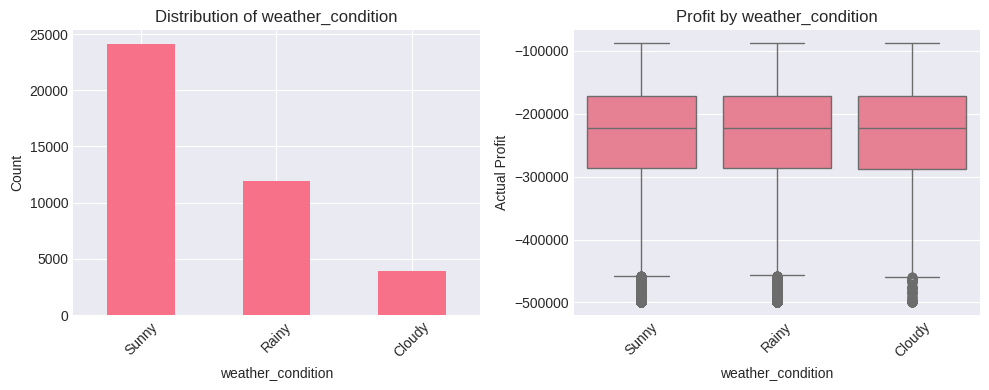


best_route_sequence:
  Unique values: 3
  Most common: 2-1-3 (count: 17321)


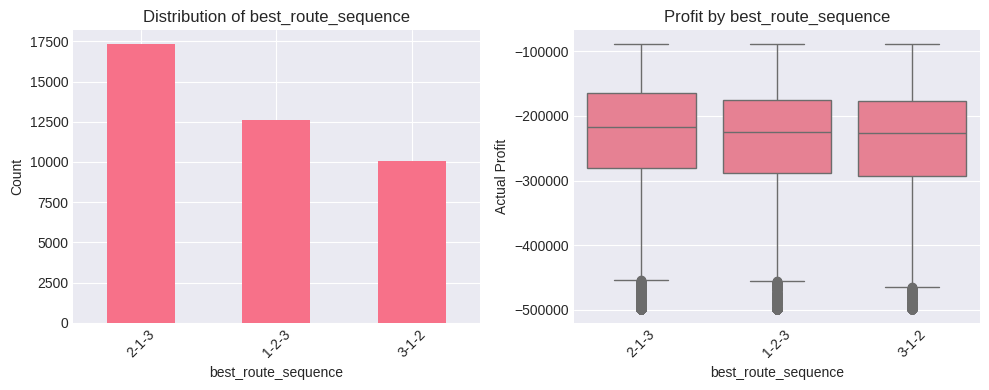


best_route_sequence:
  Unique values: 3
  Most common: 2-1-3 (count: 17321)


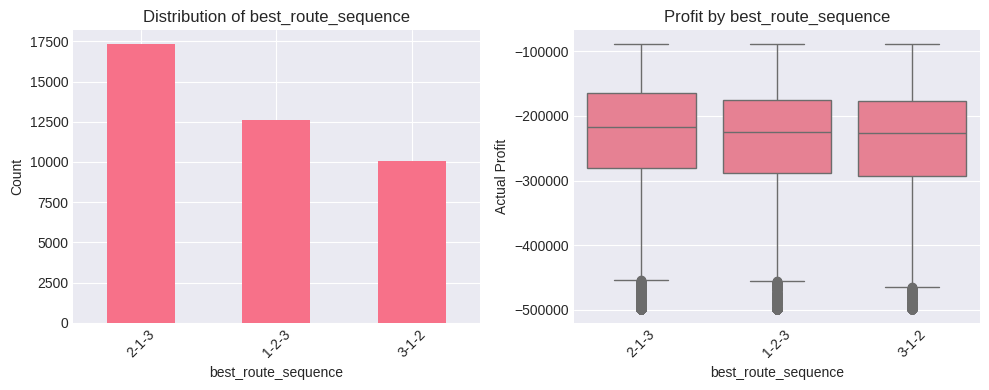


5. Time Series Analysis:


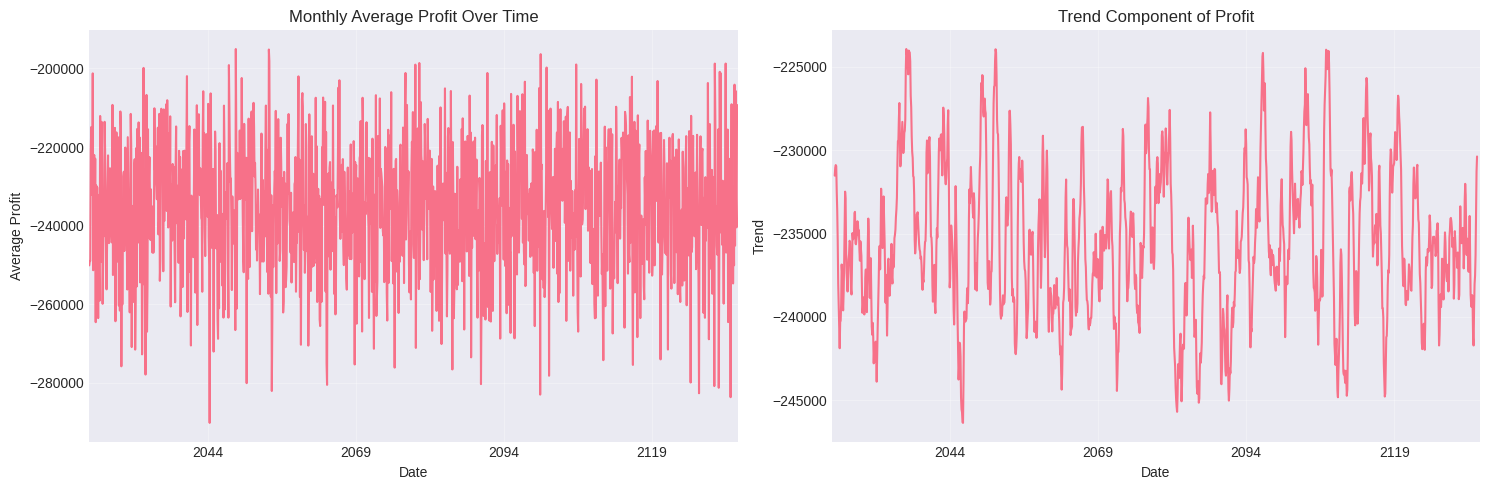


6. Feature Distributions:


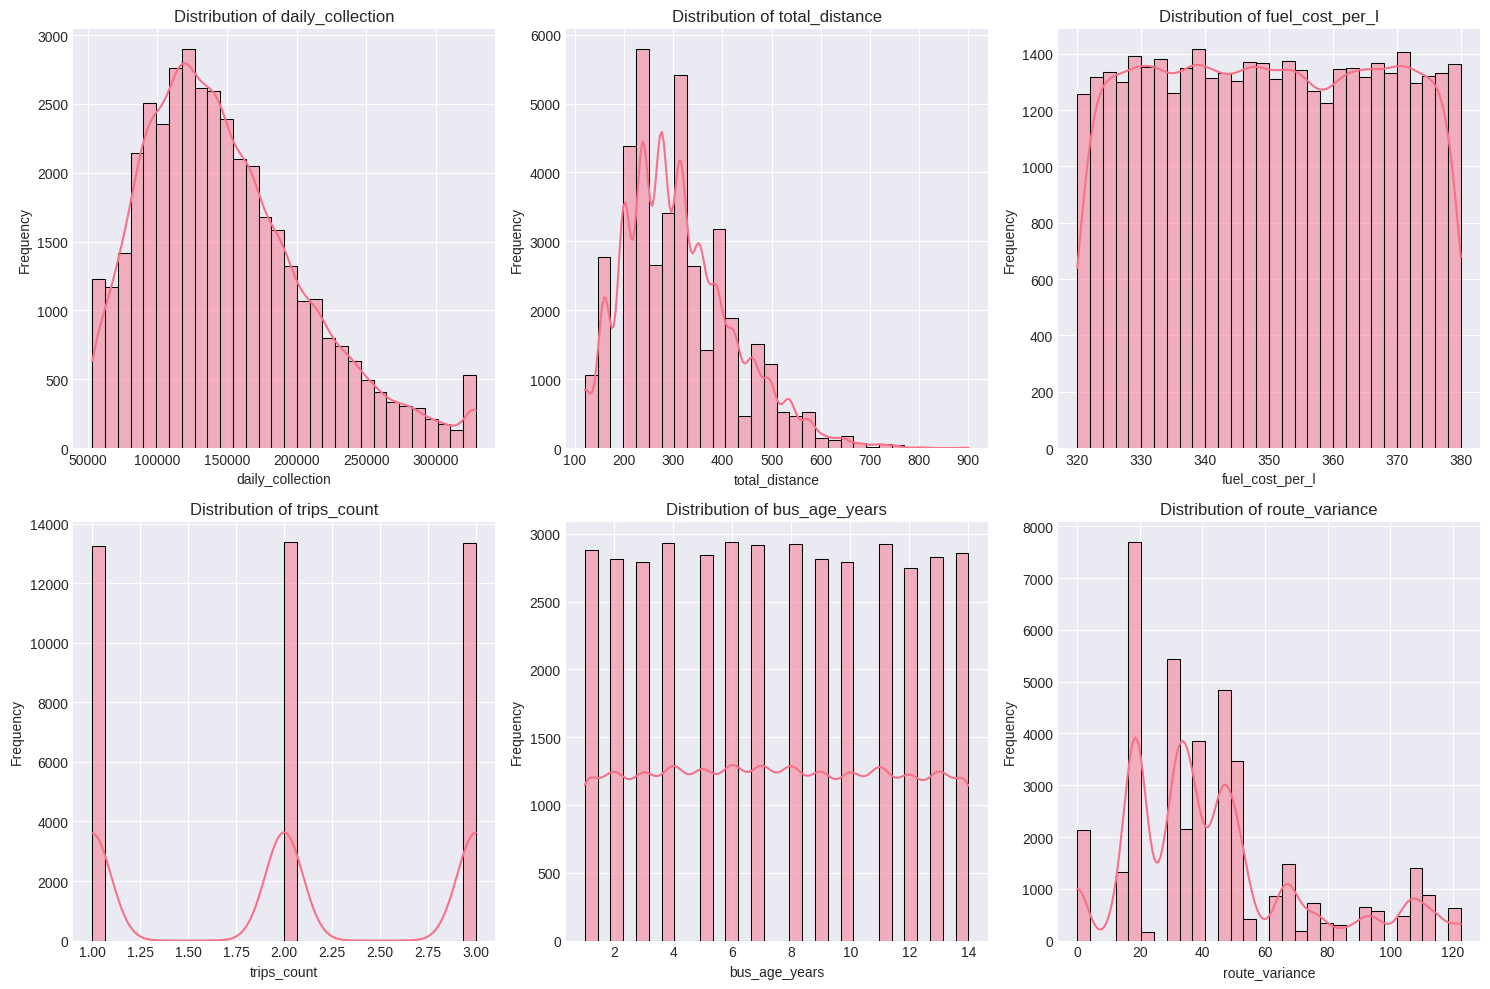


7. Pairplot of Important Features:


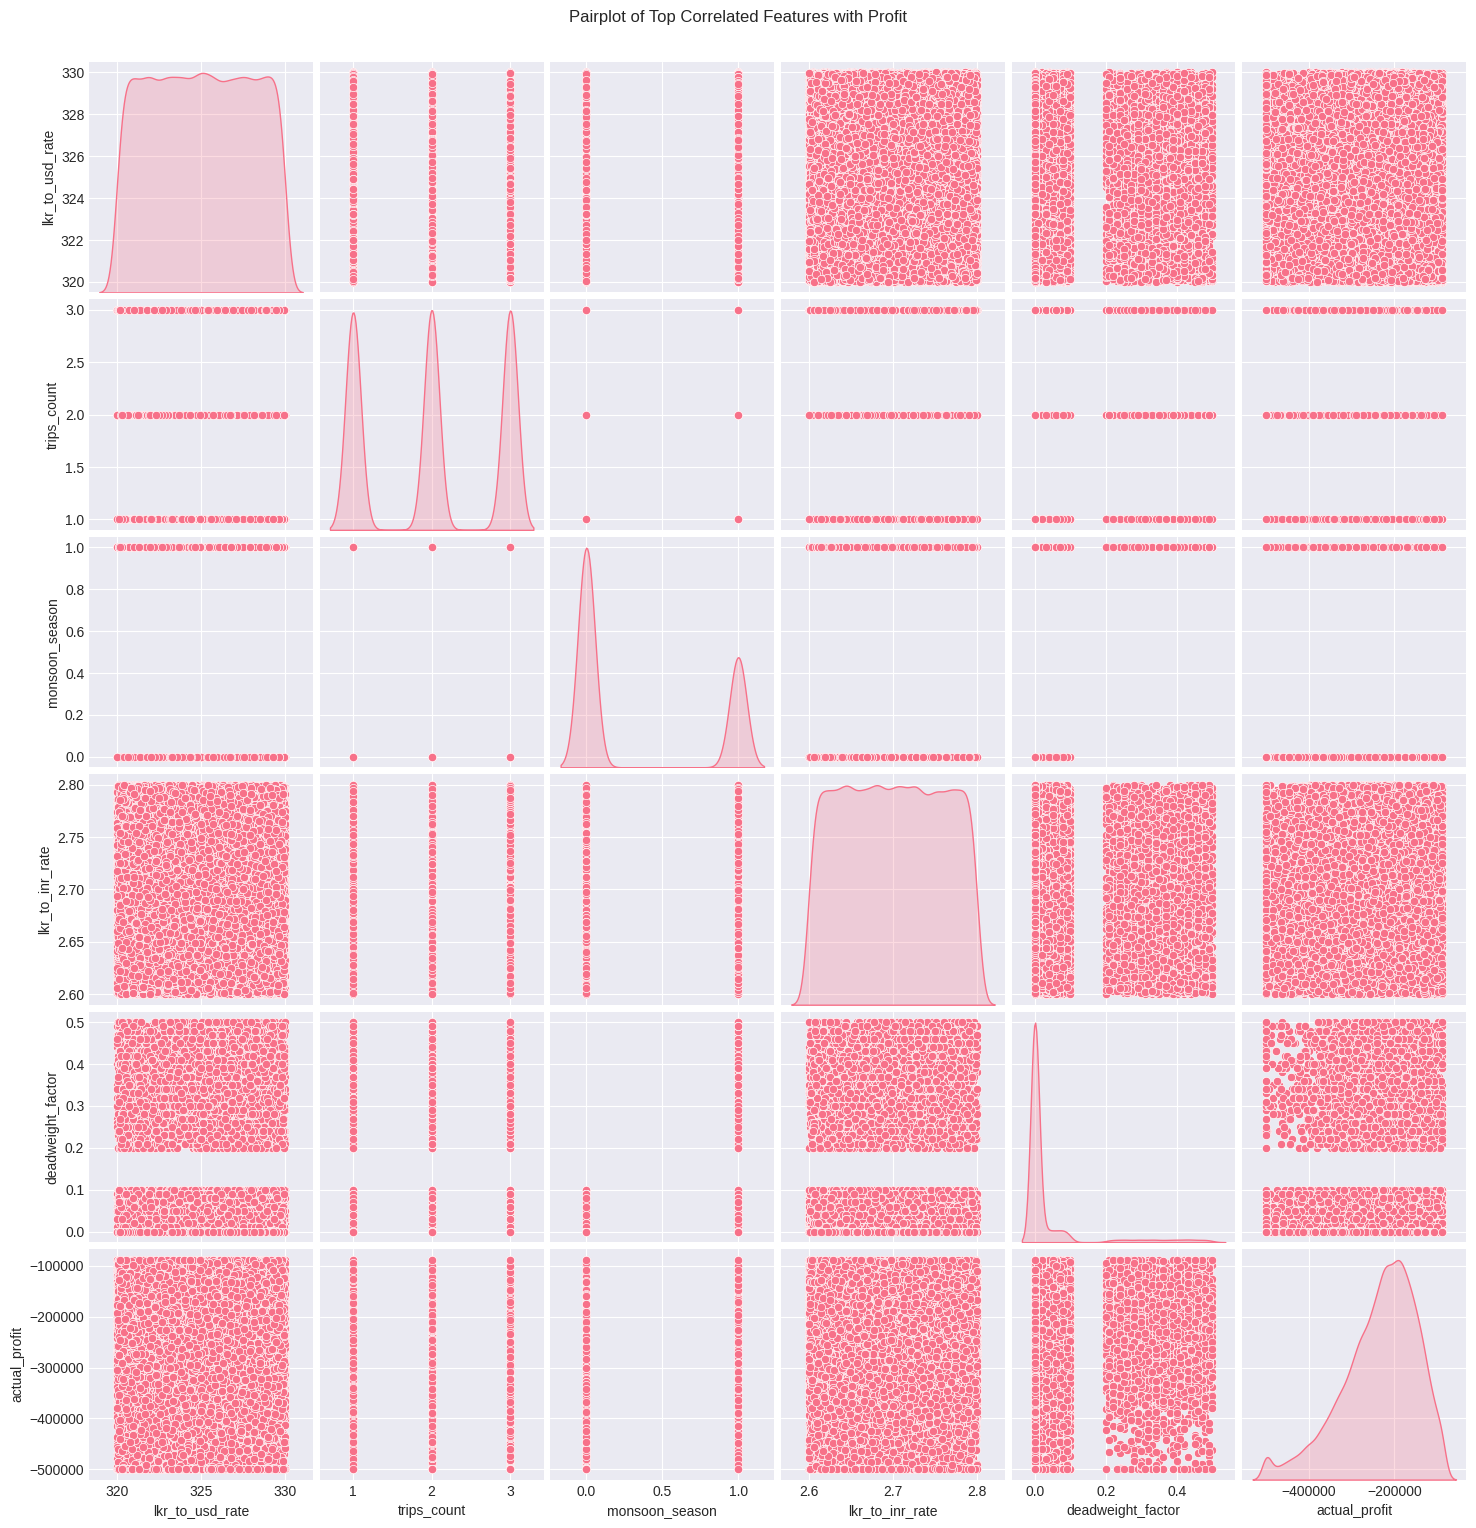


✓ EDA completed successfully!


In [4]:
print("="*80)
print("SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# 1. Basic statistics
print("\n1. Basic Statistics:")
print(df.describe())

# 2. Target variable analysis
print("\n2. Target Variable Analysis (actual_profit):")
if 'actual_profit' in df.columns:
    plt.figure(figsize=(15, 5))
    
    # Distribution
    plt.subplot(1, 3, 1)
    sns.histplot(df['actual_profit'], kde=True, bins=50)
    plt.title('Distribution of Actual Profit')
    plt.xlabel('Profit')
    plt.ylabel('Frequency')
    
    # Box plot
    plt.subplot(1, 3, 2)
    sns.boxplot(y=df['actual_profit'])
    plt.title('Box Plot of Actual Profit')
    plt.ylabel('Profit')
    
    # Q-Q plot for normality check
    plt.subplot(1, 3, 3)
    stats.probplot(df['actual_profit'], dist="norm", plot=plt)
    plt.title('Q-Q Plot for Normality Check')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical tests for normality
    print("\nNormality Tests for actual_profit:")
    
    # Shapiro-Wilk test
    stat, p = shapiro(df['actual_profit'].sample(min(5000, len(df))))
    print(f"Shapiro-Wilk Test: statistic={stat:.4f}, p-value={p:.4f}")
    if p > 0.05:
        print("  → Data appears to be normally distributed (p > 0.05)")
    else:
        print("  → Data does not appear to be normally distributed (p ≤ 0.05)")
    
    # Anderson-Darling test
    result = anderson(df['actual_profit'])
    print(f"Anderson-Darling Test: statistic={result.statistic:.4f}")
    for i in range(len(result.critical_values)):
        sl, cv = result.significance_level[i], result.critical_values[i]
        if result.statistic < cv:
            print(f"  → At {sl}% significance level, data looks normal (stat < {cv})")
        else:
            print(f"  → At {sl}% significance level, data does not look normal (stat ≥ {cv})")

# 3. Correlation analysis
print("\n3. Correlation Analysis:")
numerical_df = df.select_dtypes(include=[np.number])
if 'actual_profit' in numerical_df.columns:
    correlations = numerical_df.corr()['actual_profit'].sort_values(ascending=False)
    
    plt.figure(figsize=(10, 8))
    top_corr = correlations.drop('actual_profit').head(10)
    bottom_corr = correlations.drop('actual_profit').tail(10)
    combined_corr = pd.concat([top_corr, bottom_corr])
    
    combined_corr.plot(kind='barh', color='steelblue')
    plt.title('Top 10 Positive and Negative Correlations with Actual Profit')
    plt.xlabel('Correlation Coefficient')
    plt.tight_layout()
    plt.show()
    
    # Display correlation values
    print("\nTop 10 positive correlations:")
    print(top_corr)
    print("\nTop 10 negative correlations:")
    print(bottom_corr)

# 4. Categorical variables analysis
print("\n4. Categorical Variables Analysis:")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'best_route_sequence' in categorical_cols:
    categorical_cols.append('best_route_sequence')

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Most common: {df[col].mode()[0]} (count: {df[col].value_counts().iloc[0]})")
        
        if df[col].nunique() <= 10:  # Plot only if reasonable number of categories
            plt.figure(figsize=(10, 4))
            
            # Count plot
            plt.subplot(1, 2, 1)
            df[col].value_counts().plot(kind='bar')
            plt.title(f'Distribution of {col}')
            plt.xlabel(col)
            plt.ylabel('Count')
            plt.xticks(rotation=45)
            
            # Box plot against profit
            if 'actual_profit' in df.columns:
                plt.subplot(1, 2, 2)
                sns.boxplot(x=col, y='actual_profit', data=df)
                plt.title(f'Profit by {col}')
                plt.xlabel(col)
                plt.ylabel('Actual Profit')
                plt.xticks(rotation=45)
            
            plt.tight_layout()
            plt.show()

# 5. Time series analysis (if date available)
if 'date' in df.columns:
    print("\n5. Time Series Analysis:")
    
    # Set date as index for time series analysis
    df_time = df.set_index('date')
    
    # Resample by month
    monthly_profit = df_time['actual_profit'].resample('M').mean()
    
    plt.figure(figsize=(15, 5))
    
    # Time series plot
    plt.subplot(1, 2, 1)
    monthly_profit.plot()
    plt.title('Monthly Average Profit Over Time')
    plt.xlabel('Date')
    plt.ylabel('Average Profit')
    plt.grid(True, alpha=0.3)
    
    # Seasonal decomposition
    from statsmodels.tsa.seasonal import seasonal_decompose
    if len(monthly_profit) >= 24:  # Need at least 2 years for decomposition
        decomposition = seasonal_decompose(monthly_profit.dropna(), model='additive', period=12)
        
        plt.subplot(1, 2, 2)
        decomposition.trend.plot()
        plt.title('Trend Component of Profit')
        plt.xlabel('Date')
        plt.ylabel('Trend')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 6. Feature distributions
print("\n6. Feature Distributions:")
important_features = ['daily_collection', 'total_distance', 'fuel_cost_per_l', 
                     'trips_count', 'bus_age_years', 'route_variance']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(important_features):
    if feature in df.columns:
        ax = axes[idx]
        sns.histplot(df[feature], kde=True, ax=ax, bins=30)
        ax.set_title(f'Distribution of {feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 7. Pairplot for top correlated features
print("\n7. Pairplot of Important Features:")
top_features = correlations.drop('actual_profit').head(5).index.tolist()
if 'actual_profit' not in top_features:
    top_features.append('actual_profit')
    
if len(top_features) >= 2:
    sns.pairplot(df[top_features], diag_kind='kde')
    plt.suptitle('Pairplot of Top Correlated Features with Profit', y=1.02)
    plt.show()

print("\n✓ EDA completed successfully!")

# Section 5: Feature Engineering and 2nd Data Preprocessing

In [5]:
print("="*80)
print("SECTION 5: FEATURE ENGINEERING AND SECONDARY PREPROCESSING")
print("="*80)

# Create a copy for feature engineering
df_engineered = df.copy()

print("Original features and data types:")
original_features = pd.DataFrame({
    'Feature': df_engineered.columns,
    'DataType': df_engineered.dtypes.values,
    'UniqueValues': [df_engineered[col].nunique() for col in df_engineered.columns]
})
print(original_features.to_string())

# 1. Create new features from existing ones
print("\n1. Creating new features...")

# Route-based features
if all(col in df_engineered.columns for col in ['route_1_distance', 'route_2_distance', 'route_3_distance']):
    df_engineered['total_route_distance'] = df_engineered['route_1_distance'] + \
                                           df_engineered['route_2_distance'] + \
                                           df_engineered['route_3_distance']
    
    df_engineered['avg_route_distance'] = df_engineered['total_route_distance'] / 3
    df_engineered['max_route_distance'] = df_engineered[['route_1_distance', 
                                                        'route_2_distance', 
                                                        'route_3_distance']].max(axis=1)
    df_engineered['min_route_distance'] = df_engineered[['route_1_distance', 
                                                        'route_2_distance', 
                                                        'route_3_distance']].min(axis=1)
    df_engineered['route_distance_range'] = df_engineered['max_route_distance'] - df_engineered['min_route_distance']
    
    # Route efficiency ratio
    df_engineered['route_efficiency'] = df_engineered['total_distance'] / df_engineered['total_route_distance']
    
    print("✓ Route-based features created")

# Financial features
if all(col in df_engineered.columns for col in ['daily_collection', 'driver_salary', 'conductor_salary', 
                                               'maintenance_cost', 'backup_fuel_cost']):
    df_engineered['total_operational_cost'] = df_engineered['driver_salary'] + \
                                             df_engineered['conductor_salary'] + \
                                             df_engineered['maintenance_cost'] + \
                                             df_engineered['backup_fuel_cost']
    
    df_engineered['salary_to_collection_ratio'] = (df_engineered['driver_salary'] + 
                                                  df_engineered['conductor_salary']) / \
                                                  df_engineered['daily_collection']
    
    df_engineered['cost_per_km'] = df_engineered['total_operational_cost'] / df_engineered['total_distance']
    df_engineered['revenue_per_km'] = df_engineered['daily_collection'] / df_engineered['total_distance']
    
    # Profit margin
    df_engineered['profit_margin'] = df_engineered['actual_profit'] / df_engineered['daily_collection']
    
    print("✓ Financial features created")

# Efficiency features
if all(col in df_engineered.columns for col in ['total_distance', 'trips_count', 'fuel_efficiency']):
    df_engineered['distance_per_trip'] = df_engineered['total_distance'] / df_engineered['trips_count']
    df_engineered['estimated_fuel_consumption'] = df_engineered['total_distance'] / df_engineered['fuel_efficiency']
    
    if 'fuel_cost_per_l' in df_engineered.columns:
        df_engineered['estimated_fuel_cost'] = df_engineered['estimated_fuel_consumption'] * \
                                              df_engineered['fuel_cost_per_l']
    
    print("✓ Efficiency features created")

# Seasonal and temporal features
if 'month' in df_engineered.columns:
    # Create seasonal indicators
    seasons = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall', 10: 'Fall', 11: 'Fall'
    }
    df_engineered['season'] = df_engineered['month'].map(seasons)
    
    # Quarter of the year
    df_engineered['quarter'] = ((df_engineered['month'] - 1) // 3) + 1
    
    print("✓ Seasonal features created")

# Categorical feature encoding for route sequence
if 'best_route_sequence' in df_engineered.columns:
    # Extract individual routes from sequence
    route_sequences = df_engineered['best_route_sequence'].str.split('-')
    
    df_engineered['first_route'] = route_sequences.str[0].astype(int)
    df_engineered['second_route'] = route_sequences.str[1].astype(int)
    df_engineered['third_route'] = route_sequences.str[2].astype(int)
    
    # Create route combination features
    df_engineered['route_combo'] = df_engineered['best_route_sequence']
    
    print("✓ Route sequence features created")

# Interaction features
if all(col in df_engineered.columns for col in ['bus_age_years', 'maintenance_cost']):
    df_engineered['age_maintenance_interaction'] = df_engineered['bus_age_years'] * \
                                                  df_engineered['maintenance_cost']
    
if all(col in df_engineered.columns for col in ['weather_condition', 'deadweight_factor']):
    # Weather impact factor
    weather_impact = {
        'Sunny': 1.0,
        'Cloudy': 0.9,
        'Rainy': 0.7,
        'Stormy': 0.5
    }
    df_engineered['weather_impact_factor'] = df_engineered['weather_condition'].map(weather_impact)
    df_engineered['adjusted_deadweight'] = df_engineered['deadweight_factor'] * \
                                          df_engineered['weather_impact_factor']
    
    print("✓ Interaction features created")

# 2. Handle categorical variables
print("\n2. Processing categorical variables...")

categorical_cols = df_engineered.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Label encode ordinal categories
label_encoders = {}
for col in ['weather_condition', 'season']:
    if col in df_engineered.columns:
        le = LabelEncoder()
        df_engineered[f'{col}_encoded'] = le.fit_transform(df_engineered[col])
        label_encoders[col] = le
        print(f"  ✓ Label encoded: {col}")

# One-hot encode nominal categories
nominal_cols = [col for col in categorical_cols if col not in ['weather_condition', 'season', 
                                                              'best_route_sequence', 'route_combo']]

# For demonstration, we'll one-hot encode a few columns
for col in nominal_cols[:3]:  # Limit to first 3 to avoid too many columns
    if df_engineered[col].nunique() <= 10:  # Only if reasonable number of categories
        dummies = pd.get_dummies(df_engineered[col], prefix=col, drop_first=True)
        df_engineered = pd.concat([df_engineered, dummies], axis=1)
        print(f"  ✓ One-hot encoded: {col}")

# 3. Remove highly correlated features
print("\n3. Removing highly correlated features...")

# Calculate correlation matrix
numerical_features = df_engineered.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_engineered[numerical_features].corr()

# Find features with correlation > 0.95
high_corr_features = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            colname = corr_matrix.columns[i]
            high_corr_features.add(colname)

print(f"Highly correlated features to remove: {list(high_corr_features)}")

# Remove highly correlated features
df_engineered = df_engineered.drop(columns=list(high_corr_features))

# 4. Final dataset information
print("\n4. Final engineered dataset:")
print(f"Original shape: {df.shape}")
print(f"Engineered shape: {df_engineered.shape}")
print(f"New features created: {df_engineered.shape[1] - df.shape[1]}")

# Display all features with data types
print("\nAll features in engineered dataset:")
engineered_features = pd.DataFrame({
    'Feature': df_engineered.columns,
    'DataType': df_engineered.dtypes.values,
    'UniqueValues': [df_engineered[col].nunique() for col in df_engineered.columns],
    'MissingValues': [df_engineered[col].isnull().sum() for col in df_engineered.columns]
})
print(engineered_features.to_string())

# 5. Save engineered dataset
output_path = "bus_business_engineered.csv"
df_engineered.to_csv(output_path, index=False)
print(f"\n✓ Engineered dataset saved to: {output_path}")
print("✓ Feature engineering completed!")

SECTION 5: FEATURE ENGINEERING AND SECONDARY PREPROCESSING
Original features and data types:
                Feature        DataType  UniqueValues
0                  date  datetime64[ns]         40000
1      route_1_distance           int64             6
2      route_2_distance           int64             6
3      route_3_distance           int64             6
4      daily_collection         float64         35483
5           trips_count           int64             3
6       fuel_cost_per_l         float64          5998
7      maintenance_cost           int64           434
8         driver_salary           int64           501
9      conductor_salary           int64           501
10     backup_fuel_cost         float64         31412
11    deadweight_factor         float64            42
12    weather_condition          object             3
13          day_of_week           int64             7
14                month           int64            12
15         holiday_flag           int64    

# Section 6: Scaling with Predictable Features and Target Features Identification

SECTION 6: FEATURE SCALING AND TARGET IDENTIFICATION

1. Identifying target variable...
✓ Target variable identified: actual_profit

Target variable statistics:
  Mean: -235514.07
  Std: 87394.23
  Min: -499391.80
  Max: -88030.13
  Range: 411361.67
  Skewness: -0.7592

2. Preparing feature set...
Number of predictive features identified: 37

3. Feature importance analysis...

Top 20 most correlated features with target:
                        Feature  Correlation_with_Target
9              backup_fuel_cost                 0.948048
23           max_route_distance                 0.810321
3              daily_collection                 0.686582
26   salary_to_collection_ratio                 0.638915
18               route_variance                 0.590979
24           min_route_distance                 0.557205
29            distance_per_trip                 0.545863
1              route_2_distance                 0.536187
2              route_3_distance                 0.535745
0    

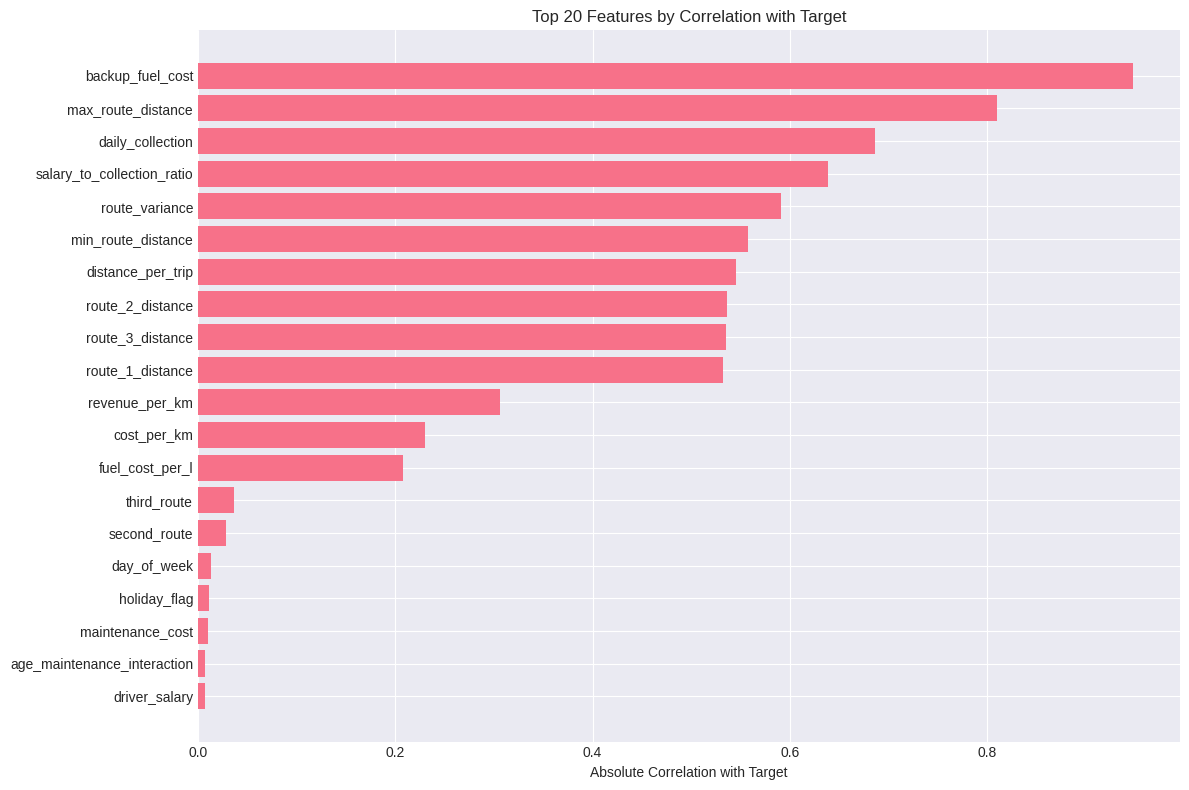


Features with correlation > 0.1: 13

4. Applying feature scaling...
Numerical features to scale: 37
Categorical features: 0

5. Final feature selection...
Selected 30 features using mutual information:
['route_1_distance', 'route_2_distance', 'route_3_distance', 'daily_collection', 'trips_count', 'fuel_cost_per_l', 'maintenance_cost', 'driver_salary', 'backup_fuel_cost', 'month', 'lkr_to_inr_rate', 'route_variance', 'fuel_efficiency', 'bus_age_years', 'year', 'day', 'max_route_distance', 'min_route_distance', 'route_efficiency', 'salary_to_collection_ratio', 'cost_per_km', 'revenue_per_km', 'distance_per_trip', 'first_route', 'second_route', 'third_route', 'age_maintenance_interaction', 'weather_impact_factor', 'weather_condition_encoded', 'season_encoded']


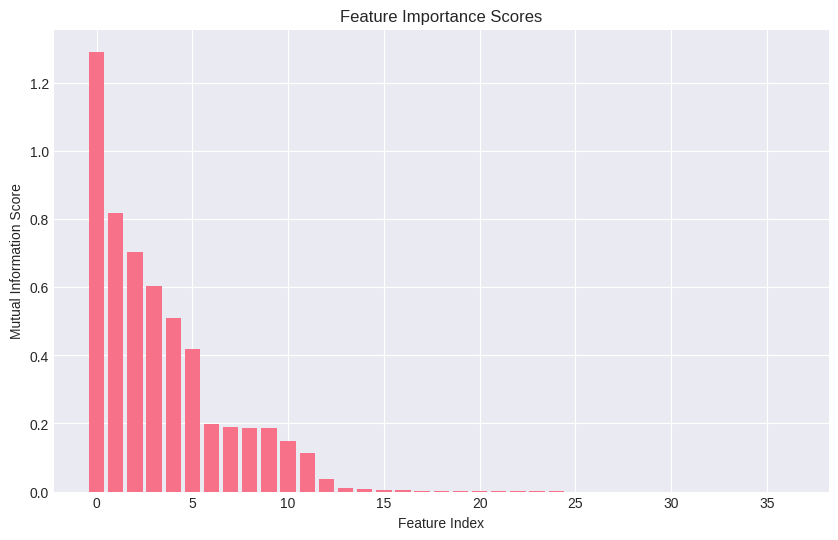


Final number of features selected for training: 30

Final features to be used for training:
  1. route_1_distance
  2. route_2_distance
  3. route_3_distance
  4. daily_collection
  5. trips_count
  6. fuel_cost_per_l
  7. maintenance_cost
  8. driver_salary
  9. backup_fuel_cost
 10. month
 11. lkr_to_inr_rate
 12. route_variance
 13. fuel_efficiency
 14. bus_age_years
 15. year
 16. day
 17. max_route_distance
 18. min_route_distance
 19. route_efficiency
 20. salary_to_collection_ratio
 21. cost_per_km
 22. revenue_per_km
 23. distance_per_trip
 24. first_route
 25. second_route
 26. third_route
 27. age_maintenance_interaction
 28. weather_impact_factor
 29. weather_condition_encoded
 30. season_encoded

6. Preparing final datasets for training...
Features shape (X): (40000, 30)
Target shape (y): (40000,)

✓ Feature scaling and selection completed!


In [6]:
print("="*80)
print("SECTION 6: FEATURE SCALING AND TARGET IDENTIFICATION")
print("="*80)

# 1. Identify target variable
print("\n1. Identifying target variable...")
target_variable = 'actual_profit'

if target_variable in df_engineered.columns:
    print(f"✓ Target variable identified: {target_variable}")
    
    # Check target variable distribution
    print(f"\nTarget variable statistics:")
    print(f"  Mean: {df_engineered[target_variable].mean():.2f}")
    print(f"  Std: {df_engineered[target_variable].std():.2f}")
    print(f"  Min: {df_engineered[target_variable].min():.2f}")
    print(f"  Max: {df_engineered[target_variable].max():.2f}")
    print(f"  Range: {df_engineered[target_variable].max() - df_engineered[target_variable].min():.2f}")
    
    # Check for class imbalance (for classification) or skewness (for regression)
    skewness = df_engineered[target_variable].skew()
    print(f"  Skewness: {skewness:.4f}")
    
    if abs(skewness) > 1:
        print("  ⚠ Warning: Target variable is highly skewed")
        print("  Consider applying transformation (log, sqrt, etc.)")
else:
    print(f"✗ Target variable '{target_variable}' not found in dataset")
    # Try to find alternative target
    possible_targets = [col for col in df_engineered.columns if 'profit' in col.lower() or 
                       'revenue' in col.lower() or 'collection' in col.lower()]
    if possible_targets:
        target_variable = possible_targets[0]
        print(f"✓ Alternative target variable identified: {target_variable}")
    else:
        print("✗ No suitable target variable found")
        target_variable = None

# 2. Prepare feature set
print("\n2. Preparing feature set...")

# Exclude non-predictive columns
exclude_columns = [
    'date',  # Date is already decomposed
    target_variable,  # Target variable
    'best_route_sequence',  # Already decomposed
    'route_combo',  # Categorical with many unique values
]

# Also exclude any columns that are derived from target
if target_variable:
    exclude_columns.extend([col for col in df_engineered.columns 
                          if 'profit' in col.lower() and col != target_variable])

# Identify predictive features
predictive_features = [col for col in df_engineered.columns 
                      if col not in exclude_columns 
                      and df_engineered[col].dtype in [np.int64, np.float64, np.int32, np.float32]]

print(f"Number of predictive features identified: {len(predictive_features)}")

# 3. Feature importance analysis using statistical methods
print("\n3. Feature importance analysis...")

if target_variable and len(predictive_features) > 0:
    X_temp = df_engineered[predictive_features].fillna(df_engineered[predictive_features].median())
    y_temp = df_engineered[target_variable]
    
    # Calculate correlation with target
    correlations = []
    for feature in predictive_features:
        corr = np.corrcoef(X_temp[feature], y_temp)[0, 1]
        correlations.append(abs(corr))
    
    # Create feature importance dataframe
    feature_importance = pd.DataFrame({
        'Feature': predictive_features,
        'Correlation_with_Target': correlations
    }).sort_values('Correlation_with_Target', ascending=False)
    
    print("\nTop 20 most correlated features with target:")
    print(feature_importance.head(20).to_string())
    
    # Visualize feature importance
    plt.figure(figsize=(12, 8))
    top_20 = feature_importance.head(20)
    plt.barh(range(len(top_20)), top_20['Correlation_with_Target'])
    plt.yticks(range(len(top_20)), top_20['Feature'])
    plt.xlabel('Absolute Correlation with Target')
    plt.title('Top 20 Features by Correlation with Target')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Select top features based on correlation
    correlation_threshold = 0.1  # Minimum absolute correlation
    selected_features_corr = feature_importance[
        feature_importance['Correlation_with_Target'].abs() > correlation_threshold
    ]['Feature'].tolist()
    
    print(f"\nFeatures with correlation > {correlation_threshold}: {len(selected_features_corr)}")

# 4. Feature scaling
print("\n4. Applying feature scaling...")

# Separate numerical and categorical features
numerical_features = [col for col in predictive_features 
                     if df_engineered[col].dtype in [np.float64, np.float32, np.int64, np.int32]]
categorical_features = [col for col in predictive_features 
                       if col not in numerical_features and df_engineered[col].dtype == 'object']

print(f"Numerical features to scale: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Create preprocessing pipelines
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create column transformer
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# 5. Final feature selection
print("\n5. Final feature selection...")

# Use statistical tests for feature selection
if target_variable and len(predictive_features) > 10:
    X = df_engineered[predictive_features]
    y = df_engineered[target_variable]
    
    # Handle missing values temporarily
    X_filled = X.fillna(X.median())
    
    # Use mutual information for feature selection
    selector = SelectKBest(score_func=mutual_info_regression, k=min(30, len(predictive_features)))
    selector.fit(X_filled, y)
    
    # Get selected features
    selected_indices = selector.get_support(indices=True)
    selected_features = [predictive_features[i] for i in selected_indices]
    
    print(f"Selected {len(selected_features)} features using mutual information:")
    print(selected_features)
    
    # Visualize feature scores
    feature_scores = pd.DataFrame({
        'Feature': predictive_features,
        'Score': selector.scores_
    }).sort_values('Score', ascending=False)
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(feature_scores)), feature_scores['Score'])
    plt.xlabel('Feature Index')
    plt.ylabel('Mutual Information Score')
    plt.title('Feature Importance Scores')
    plt.show()
    
    # Use selected features
    final_features = selected_features
else:
    # Use all predictive features
    final_features = predictive_features

print(f"\nFinal number of features selected for training: {len(final_features)}")
print("\nFinal features to be used for training:")
for i, feature in enumerate(final_features, 1):
    print(f"{i:3d}. {feature}")

# 6. Prepare final datasets
print("\n6. Preparing final datasets for training...")
X = df_engineered[final_features]
y = df_engineered[target_variable] if target_variable else None

print(f"Features shape (X): {X.shape}")
if y is not None:
    print(f"Target shape (y): {y.shape}")

print("\n✓ Feature scaling and selection completed!")

# Section 7: Data Splitting for Train-Test

SECTION 7: DATA SPLITTING FOR TRAIN-TEST
Features shape (X): (40000, 30)
Target shape (y): (40000,)

Handling missing values in features...
✓ No missing values found in features

Splitting data into training and testing sets...

DATA SPLIT SUMMARY
Total samples: 40,000
Training set size: 32,000 (80.0%)
Test set size: 8,000 (20.0%)
Number of features: 30

Training features (first 20):
  1. route_1_distance
  2. route_2_distance
  3. route_3_distance
  4. daily_collection
  5. trips_count
  6. fuel_cost_per_l
  7. maintenance_cost
  8. driver_salary
  9. backup_fuel_cost
 10. month
 11. lkr_to_inr_rate
 12. route_variance
 13. fuel_efficiency
 14. bus_age_years
 15. year
 16. day
 17. max_route_distance
 18. min_route_distance
 19. route_efficiency
 20. salary_to_collection_ratio
... and 10 more features


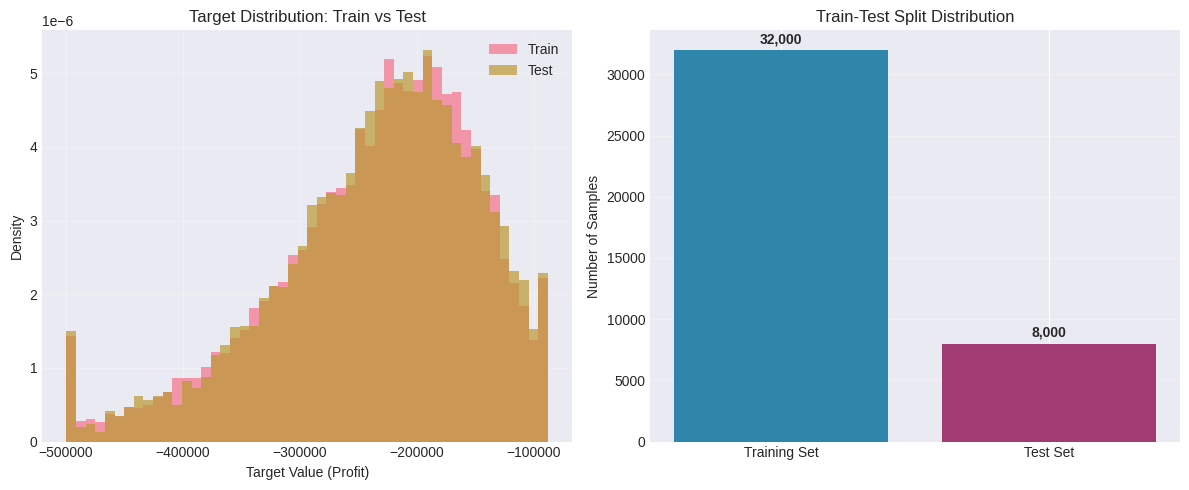


STATISTICAL COMPARISON: TRAIN VS TEST
      Training Set   Test Set  Difference (%)
Mean    -235708.14 -234737.78            0.41
Std       87444.19   87195.23           -0.28
Min     -499391.80 -499391.80            0.00
25%     -286392.75 -285331.75            0.37
50%     -222027.00 -222744.00           -0.32
75%     -171380.75 -171437.25           -0.03
Max      -88030.13  -88030.13            0.00

Checking feature distributions...


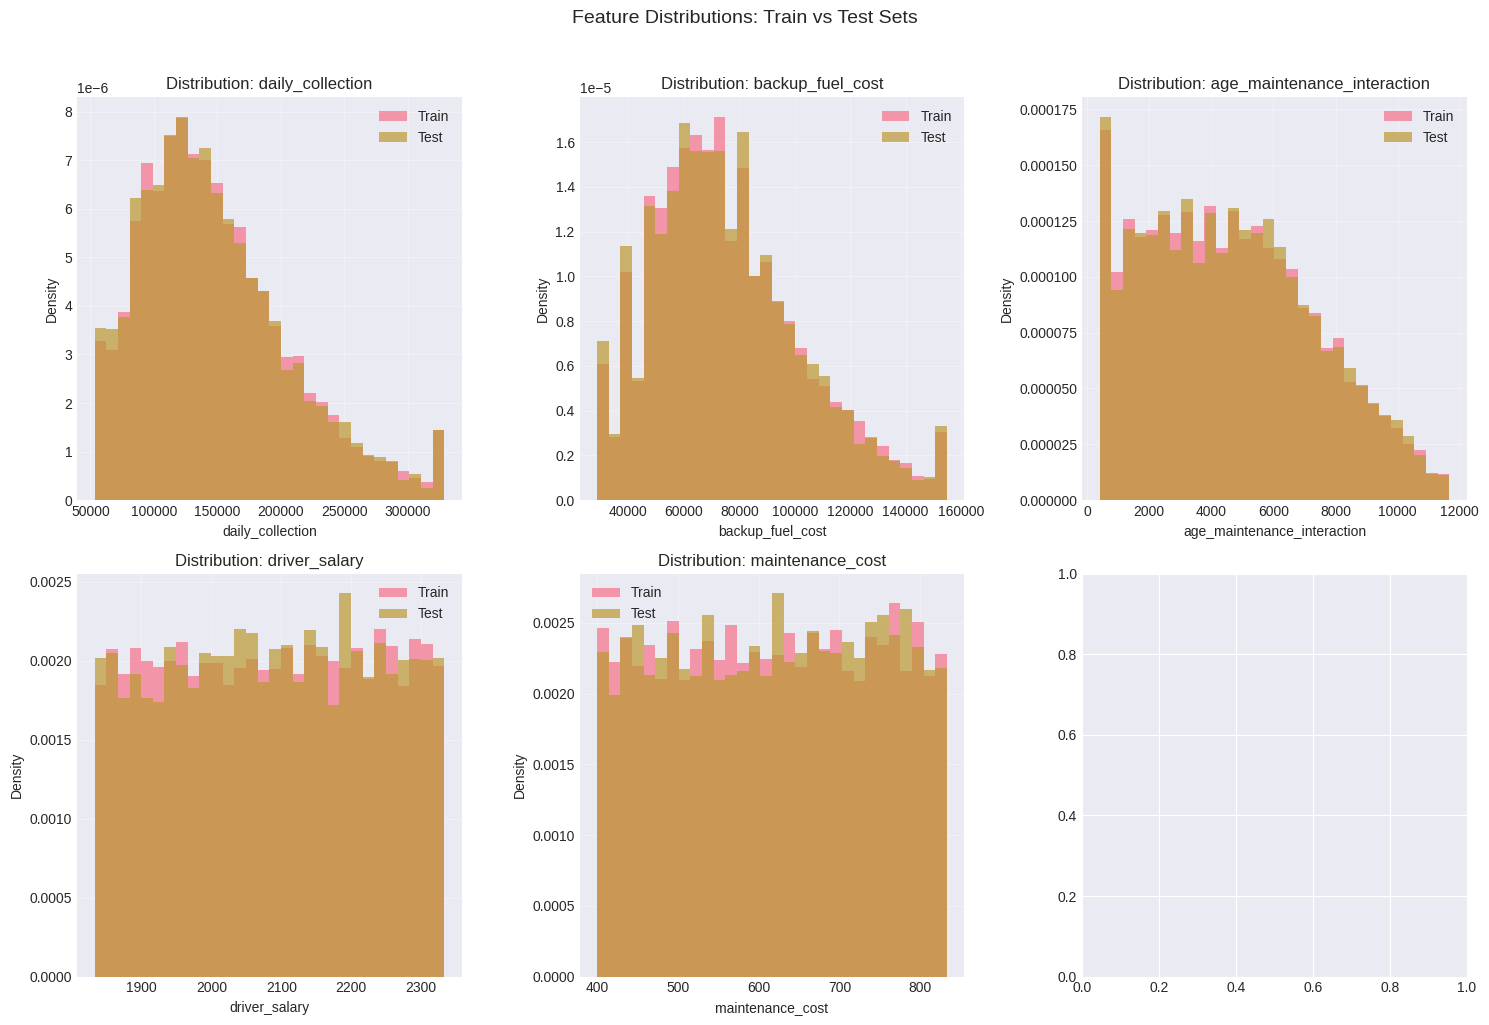


Saving train-test split data...
✓ Train-test split data saved in 'train_test_data' directory
✓ Data splitting completed successfully!


In [7]:
print("="*80)
print("SECTION 7: DATA SPLITTING FOR TRAIN-TEST")
print("="*80)

# 1. Check if we have target variable
if target_variable is None or target_variable not in df_engineered.columns:
    print("✗ Error: Target variable not found. Cannot proceed with train-test split.")
    print("Please check if 'actual_profit' column exists in the dataset.")
else:
    # 2. Prepare features and target
    X = df_engineered[final_features]
    y = df_engineered[target_variable]
    
    print(f"Features shape (X): {X.shape}")
    print(f"Target shape (y): {y.shape}")
    
    # 3. Handle missing values in features
    print("\nHandling missing values in features...")
    missing_before = X.isnull().sum().sum()
    if missing_before > 0:
        print(f"Missing values before imputation: {missing_before}")
        # Simple imputation for missing values
        X = X.fillna(X.median())
        missing_after = X.isnull().sum().sum()
        print(f"Missing values after imputation: {missing_after}")
    else:
        print("✓ No missing values found in features")
    
    # 4. Split data into training and testing sets
    print("\nSplitting data into training and testing sets...")
    
    # Use stratified split if target has significant skew
    # For regression, we'll use random split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2,  # 80% training, 20% testing
        random_state=42,  # For reproducibility
        shuffle=True
    )
    
    # 5. Display split information
    print("\n" + "="*50)
    print("DATA SPLIT SUMMARY")
    print("="*50)
    print(f"Total samples: {len(X):,}")
    print(f"Training set size: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
    print(f"Test set size: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
    print(f"Number of features: {X_train.shape[1]}")
    
    print("\nTraining features (first 20):")
    for i, feature in enumerate(final_features[:20], 1):
        print(f"{i:3d}. {feature}")
    
    if len(final_features) > 20:
        print(f"... and {len(final_features) - 20} more features")
    
    # 6. Visualize the split distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Target distribution in train vs test
    axes[0].hist(y_train, bins=50, alpha=0.7, label='Train', density=True)
    axes[0].hist(y_test, bins=50, alpha=0.7, label='Test', density=True)
    axes[0].set_xlabel('Target Value (Profit)')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Target Distribution: Train vs Test')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Sample count visualization
    split_counts = [len(X_train), len(X_test)]
    split_labels = ['Training Set', 'Test Set']
    colors = ['#2E86AB', '#A23B72']
    
    axes[1].bar(split_labels, split_counts, color=colors)
    axes[1].set_ylabel('Number of Samples')
    axes[1].set_title('Train-Test Split Distribution')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Add count labels on bars
    for i, count in enumerate(split_counts):
        axes[1].text(i, count + max(split_counts)*0.01, f'{count:,}', 
                    ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # 7. Statistical comparison
    print("\n" + "="*50)
    print("STATISTICAL COMPARISON: TRAIN VS TEST")
    print("="*50)
    
    train_stats = {
        'Mean': y_train.mean(),
        'Std': y_train.std(),
        'Min': y_train.min(),
        '25%': y_train.quantile(0.25),
        '50%': y_train.median(),
        '75%': y_train.quantile(0.75),
        'Max': y_train.max()
    }
    
    test_stats = {
        'Mean': y_test.mean(),
        'Std': y_test.std(),
        'Min': y_test.min(),
        '25%': y_test.quantile(0.25),
        '50%': y_test.median(),
        '75%': y_test.quantile(0.75),
        'Max': y_test.max()
    }
    
    # Create DataFrames separately and then combine
    train_stats_df = pd.DataFrame.from_dict(train_stats, orient='index', columns=['Training Set'])
    test_stats_df = pd.DataFrame.from_dict(test_stats, orient='index', columns=['Test Set'])
    
    # Combine the DataFrames
    stats_df = pd.concat([train_stats_df, test_stats_df], axis=1)
    
    # Calculate percentage difference
    stats_df['Difference (%)'] = stats_df.apply(
        lambda row: ((row['Test Set'] - row['Training Set']) / abs(row['Training Set']) * 100 
                    if row['Training Set'] != 0 else 0),
        axis=1
    )
    
    print(stats_df.round(2))
    
    # 8. Feature distribution check
    print("\nChecking feature distributions...")
    
    # Select a few important features to compare
    important_features = []
    if len(final_features) >= 5:
        # Use features with highest variance
        variances = X.var().sort_values(ascending=False)
        important_features = variances.head(5).index.tolist()
    
    if important_features:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, feature in enumerate(important_features[:6]):
            ax = axes[idx]
            ax.hist(X_train[feature], bins=30, alpha=0.7, label='Train', density=True)
            ax.hist(X_test[feature], bins=30, alpha=0.7, label='Test', density=True)
            ax.set_xlabel(feature)
            ax.set_ylabel('Density')
            ax.set_title(f'Distribution: {feature}')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.suptitle('Feature Distributions: Train vs Test Sets', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()
    
    # 9. Save the split data
    print("\nSaving train-test split data...")
    
    # Create directory for split data
    os.makedirs('train_test_data', exist_ok=True)
    
    # Save as CSV
    X_train.to_csv('train_test_data/X_train.csv', index=False)
    X_test.to_csv('train_test_data/X_test.csv', index=False)
    y_train.to_csv('train_test_data/y_train.csv', index=False)
    y_test.to_csv('train_test_data/y_test.csv', index=False)
    
    # Save as numpy arrays
    np.save('train_test_data/X_train.npy', X_train.values)
    np.save('train_test_data/X_test.npy', X_test.values)
    np.save('train_test_data/y_train.npy', y_train.values)
    np.save('train_test_data/y_test.npy', y_test.values)
    
    # Save feature names
    with open('train_test_data/feature_names.pkl', 'wb') as f:
        pickle.dump(final_features, f)
    
    print("✓ Train-test split data saved in 'train_test_data' directory")
    print("✓ Data splitting completed successfully!")

# Section 8: Model Defining and Training

SECTION 8: MODEL DEFINITION AND TRAINING

1. Preparing data for modeling...
✓ Loaded pre-split data from files
Training data shape: X_train=(32000, 30), y_train=(32000,)
Test data shape: X_test=(8000, 30), y_test=(8000,)
Number of features: 30

2. Scaling features...
✓ Features and target scaled

3. Defining regression models for comparison...
✓ Defined 11 different models

Models to be trained:
 1. Linear Regression
 2. Ridge Regression
 3. Lasso Regression
 4. ElasticNet
 5. Decision Tree
 6. Random Forest
 7. Gradient Boosting
 8. SVR
 9. K-Neighbors
10. XGBoost
11. LightGBM

4. Training and evaluating models...

Training Linear Regression...

Linear Regression Performance:
  Training Time: 0.03 seconds
  Train R²: 0.9980
  Test R²:  0.9979
  Train MAE: 1207.60
  Test MAE:  1224.59
  Train RMSE: 3917.01
  Test RMSE:  3965.60
  Test MAPE:  0.0052
  ✓ Good generalization (difference: 0.000)

Training Ridge Regression...

Ridge Regression Performance:
  Training Time: 0.03 seconds
  Tr

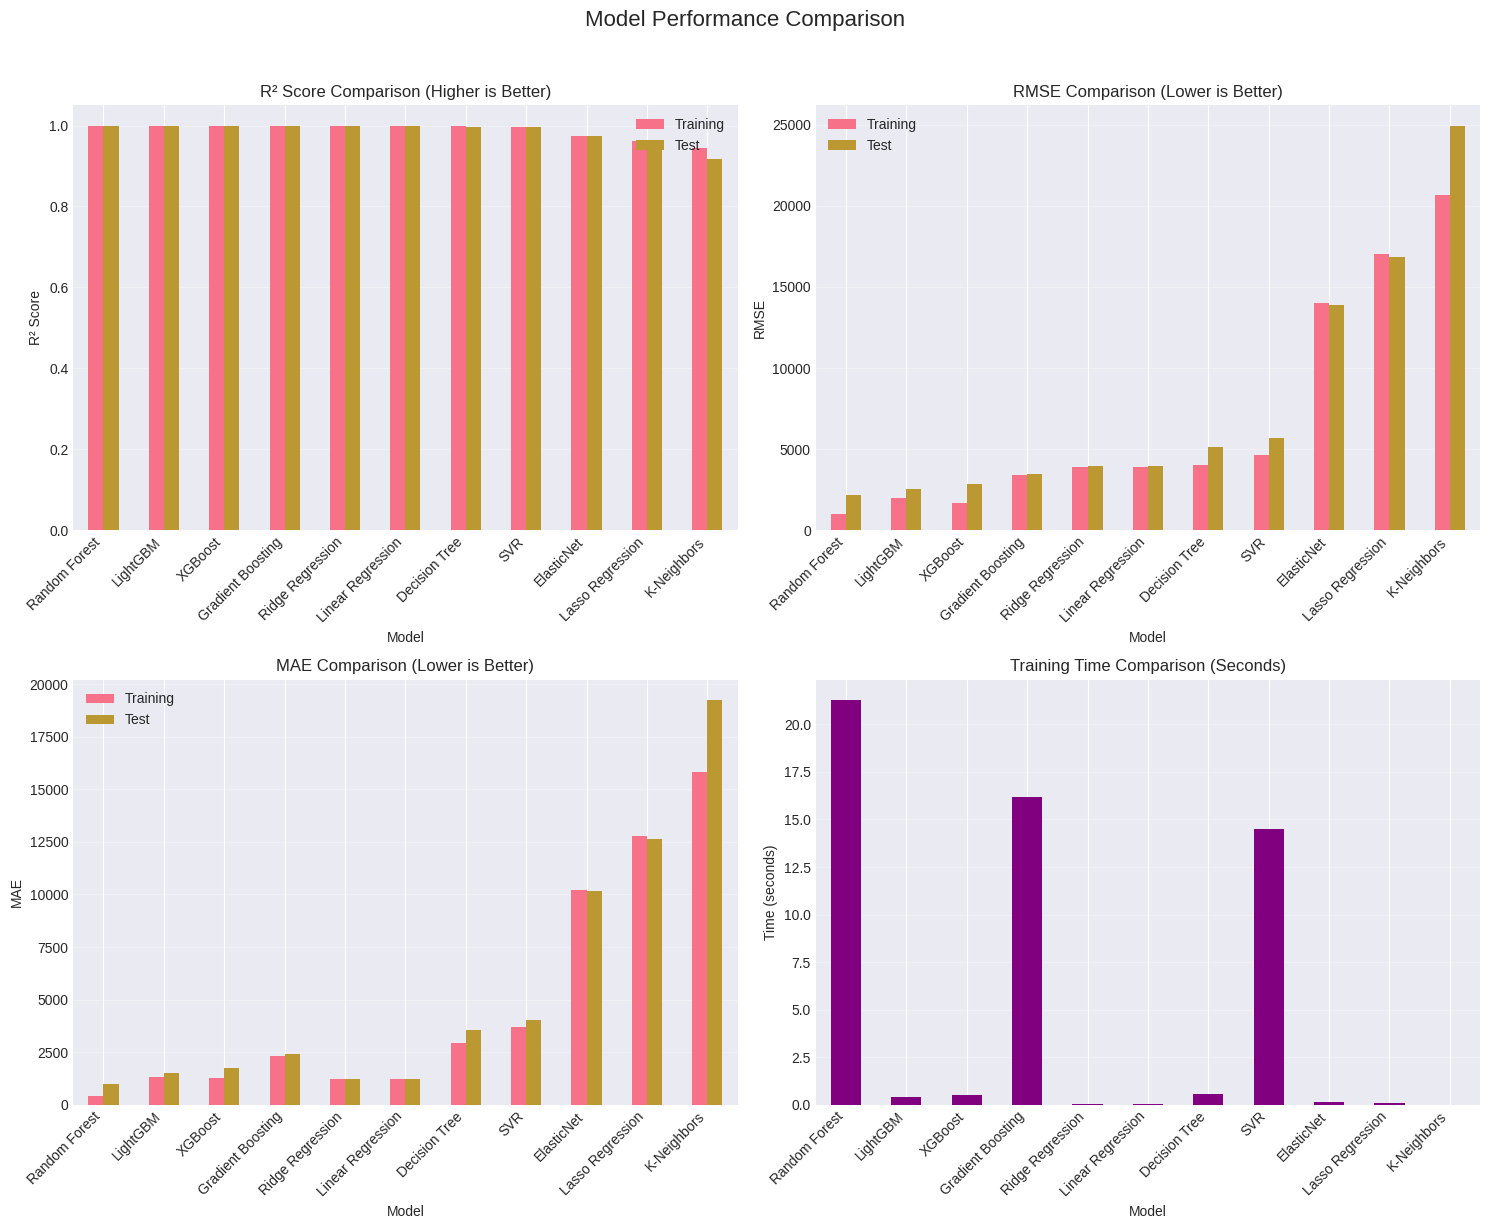


BEST MODEL SELECTION

Models ranked by composite score:
                   Test R2   Test RMSE    Test MAE  Overfitting Score  Training Time (s)  Composite Score
LightGBM            0.9992   2531.3437   1494.4604             0.0003             0.4033           0.9820
XGBoost             0.9989   2873.4339   1736.4305             0.0007             0.5087           0.9727
Linear Regression   0.9979   3965.5968   1224.5883             0.0001             0.0251           0.9702
Ridge Regression    0.9979   3962.2696   1236.1062             0.0001             0.0272           0.9702
Decision Tree       0.9965   5149.9422   3558.3203             0.0014             0.5765           0.9221
Random Forest       0.9994   2141.1891    967.4903             0.0005            21.2798           0.8916
Gradient Boosting   0.9984   3468.3609   2414.5527             0.0001            16.1812           0.8909
SVR                 0.9958   5682.8454   4040.4460             0.0015            14.4828       

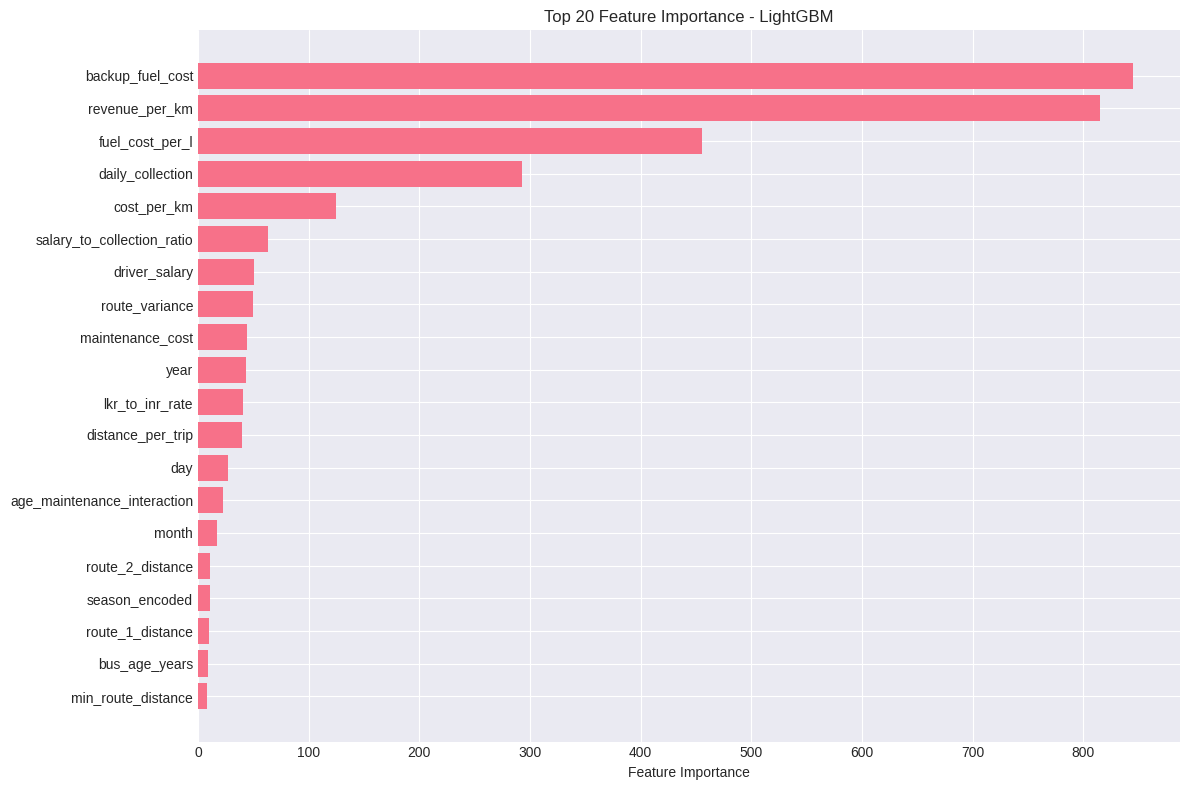


✓ Best model saved successfully!
  Model directory: best_model_lightgbm
  Model file: best_model_lightgbm/model.pkl
  Performance metrics: best_model_lightgbm/performance_metrics.json

FEATURES USED IN TRAINING PROCESS

Total features used: 30

Feature list:
  1. route_1_distance
  2. route_2_distance
  3. route_3_distance
  4. daily_collection
  5. trips_count
  6. fuel_cost_per_l
  7. maintenance_cost
  8. driver_salary
  9. backup_fuel_cost
 10. month
 11. lkr_to_inr_rate
 12. route_variance
 13. fuel_efficiency
 14. bus_age_years
 15. year
 16. day
 17. max_route_distance
 18. min_route_distance
 19. route_efficiency
 20. salary_to_collection_ratio
 21. cost_per_km
 22. revenue_per_km
 23. distance_per_trip
 24. first_route
 25. second_route
 26. third_route
 27. age_maintenance_interaction
 28. weather_impact_factor
 29. weather_condition_encoded
 30. season_encoded

✓ Model training and selection completed successfully!

END OF SECTION 8


In [8]:
print("="*80)
print("SECTION 8: MODEL DEFINITION AND TRAINING")
print("="*80)

# Import time module for tracking training duration
import time

# 1. Prepare data for modeling
print("\n1. Preparing data for modeling...")

# Load or use existing split data
try:
    X_train = pd.read_csv('train_test_data/X_train.csv')
    X_test = pd.read_csv('train_test_data/X_test.csv')
    y_train = pd.read_csv('train_test_data/y_train.csv').iloc[:, 0]
    y_test = pd.read_csv('train_test_data/y_test.csv').iloc[:, 0]
    
    with open('train_test_data/feature_names.pkl', 'rb') as f:
        final_features = pickle.load(f)
    
    print("✓ Loaded pre-split data from files")
except:
    print("✗ Could not load pre-split data, using current split")
    # Ensure data is available from previous section
    if 'X_train' not in locals():
        print("✗ Error: No training data available")
        print("Please run Section 7 first or provide data")
        X_train, X_test, y_train, y_test, final_features = None, None, None, None, None

if X_train is not None:
    print(f"Training data shape: X_train={X_train.shape}, y_train={y_train.shape}")
    print(f"Test data shape: X_test={X_test.shape}, y_test={y_test.shape}")
    print(f"Number of features: {len(final_features)}")
    
    # 2. Scale the features
    print("\n2. Scaling features...")
    
    # Initialize scalers
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()
    
    # Scale features
    X_train_scaled = X_scaler.fit_transform(X_train)
    X_test_scaled = X_scaler.transform(X_test)
    
    # Scale target (optional, but helpful for some models)
    y_train_reshaped = y_train.values.reshape(-1, 1)
    y_test_reshaped = y_test.values.reshape(-1, 1)
    
    y_train_scaled = y_scaler.fit_transform(y_train_reshaped).flatten()
    y_test_scaled = y_scaler.transform(y_test_reshaped).flatten()
    
    print("✓ Features and target scaled")
    
    # 3. Define models for comparison
    print("\n3. Defining regression models for comparison...")
    
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'Lasso Regression': Lasso(alpha=0.1, max_iter=10000),
        'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
        'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
        'K-Neighbors': KNeighborsRegressor(n_neighbors=5),
        'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
        'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
    }
    
    print(f"✓ Defined {len(models)} different models")
    print("\nModels to be trained:")
    for i, (name, model) in enumerate(models.items(), 1):
        print(f"{i:2d}. {name}")
    
    # 4. Model training and evaluation
    print("\n4. Training and evaluating models...")
    
    results = {}
    training_times = {}
    
    for name, model in models.items():
        print(f"\n{'='*60}")
        print(f"Training {name}...")
        print('='*60)
        
        try:
            # Train model
            start_time = time.time()
            model.fit(X_train_scaled, y_train_scaled)
            training_time = time.time() - start_time
            training_times[name] = training_time
            
            # Make predictions
            y_train_pred_scaled = model.predict(X_train_scaled)
            y_test_pred_scaled = model.predict(X_test_scaled)
            
            # Inverse transform predictions to original scale
            y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
            y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()
            
            # Calculate metrics
            metrics = {
                'Training Time (s)': training_time,
                
                # Training metrics
                'Train R2': r2_score(y_train, y_train_pred),
                'Train MAE': mean_absolute_error(y_train, y_train_pred),
                'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
                'Train MAPE': mean_absolute_percentage_error(y_train, y_train_pred),
                
                # Test metrics
                'Test R2': r2_score(y_test, y_test_pred),
                'Test MAE': mean_absolute_error(y_test, y_test_pred),
                'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
                'Test MAPE': mean_absolute_percentage_error(y_test, y_test_pred),
                
                # Additional metrics
                'Explained Variance': explained_variance_score(y_test, y_test_pred),
                'Max Error': max_error(y_test, y_test_pred)
            }
            
            results[name] = metrics
            
            # Display metrics
            print(f"\n{name} Performance:")
            print(f"  Training Time: {training_time:.2f} seconds")
            print(f"  Train R²: {metrics['Train R2']:.4f}")
            print(f"  Test R²:  {metrics['Test R2']:.4f}")
            print(f"  Train MAE: {metrics['Train MAE']:.2f}")
            print(f"  Test MAE:  {metrics['Test MAE']:.2f}")
            print(f"  Train RMSE: {metrics['Train RMSE']:.2f}")
            print(f"  Test RMSE:  {metrics['Test RMSE']:.2f}")
            print(f"  Test MAPE:  {metrics['Test MAPE']:.4f}")
            
            # Check for overfitting
            overfit_score = metrics['Train R2'] - metrics['Test R2']
            if overfit_score > 0.1:
                print(f"  ⚠ Warning: Potential overfitting (difference: {overfit_score:.3f})")
            elif overfit_score < -0.05:
                print(f"  ⚠ Warning: Potential underfitting (difference: {overfit_score:.3f})")
            else:
                print(f"  ✓ Good generalization (difference: {overfit_score:.3f})")
                
        except Exception as e:
            print(f"✗ Error training {name}: {str(e)}")
            results[name] = None
    
    # 5. Results comparison
    print("\n" + "="*80)
    print("MODEL COMPARISON RESULTS")
    print("="*80)
    
    # Check if any models were trained successfully
    successful_models = {k: v for k, v in results.items() if v is not None}
    
    if not successful_models:
        print("✗ No models were trained successfully. Check the errors above.")
    else:
        # Create results dataframe
        results_df = pd.DataFrame.from_dict(successful_models, orient='index')
        
        # Sort by Test R2 score (primary metric)
        results_df = results_df.sort_values('Test R2', ascending=False)
        
        print(f"\nSuccessfully trained {len(results_df)} models")
        print("\nAll Models Sorted by Test R² Score:")
        print(results_df[['Test R2', 'Test RMSE', 'Test MAE', 'Training Time (s)']].round(4))
        
        # 6. Visualize model comparison
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # R² Score comparison
        ax1 = axes[0, 0]
        results_df[['Train R2', 'Test R2']].plot(kind='bar', ax=ax1)
        ax1.set_title('R² Score Comparison (Higher is Better)')
        ax1.set_ylabel('R² Score')
        ax1.set_xlabel('Model')
        ax1.legend(['Training', 'Test'])
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.set_xticklabels(results_df.index, rotation=45, ha='right')
        
        # RMSE comparison
        ax2 = axes[0, 1]
        results_df[['Train RMSE', 'Test RMSE']].plot(kind='bar', ax=ax2)
        ax2.set_title('RMSE Comparison (Lower is Better)')
        ax2.set_ylabel('RMSE')
        ax2.set_xlabel('Model')
        ax2.legend(['Training', 'Test'])
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.set_xticklabels(results_df.index, rotation=45, ha='right')
        
        # MAE comparison
        ax3 = axes[1, 0]
        results_df[['Train MAE', 'Test MAE']].plot(kind='bar', ax=ax3)
        ax3.set_title('MAE Comparison (Lower is Better)')
        ax3.set_ylabel('MAE')
        ax3.set_xlabel('Model')
        ax3.legend(['Training', 'Test'])
        ax3.grid(True, alpha=0.3, axis='y')
        ax3.set_xticklabels(results_df.index, rotation=45, ha='right')
        
        # Training time comparison
        ax4 = axes[1, 1]
        results_df['Training Time (s)'].plot(kind='bar', ax=ax4, color='purple')
        ax4.set_title('Training Time Comparison (Seconds)')
        ax4.set_ylabel('Time (seconds)')
        ax4.set_xlabel('Model')
        ax4.grid(True, alpha=0.3, axis='y')
        ax4.set_xticklabels(results_df.index, rotation=45, ha='right')
        
        plt.suptitle('Model Performance Comparison', fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()
        
        # 7. Select best model
        print("\n" + "="*80)
        print("BEST MODEL SELECTION")
        print("="*80)
        
        # Criteria for best model:
        # 1. High Test R²
        # 2. Low overfitting (small difference between train and test R²)
        # 3. Reasonable training time
        # 4. Good RMSE and MAE
        
        # Calculate overfitting score
        results_df['Overfitting Score'] = results_df['Train R2'] - results_df['Test R2']
        
        # Normalize metrics for composite score
        normalized_df = results_df.copy()
        
        # For metrics where higher is better (R², Explained Variance)
        for col in ['Test R2', 'Explained Variance']:
            col_min = normalized_df[col].min()
            col_max = normalized_df[col].max()
            if col_max > col_min:  # Avoid division by zero
                normalized_df[f'{col}_norm'] = (normalized_df[col] - col_min) / (col_max - col_min)
            else:
                normalized_df[f'{col}_norm'] = 0.5  # Neutral value if all same
        
        # For metrics where lower is better (RMSE, MAE, MAPE, Overfitting, Training Time)
        for col in ['Test RMSE', 'Test MAE', 'Test MAPE', 'Overfitting Score', 'Training Time (s)']:
            col_min = normalized_df[col].min()
            col_max = normalized_df[col].max()
            if col_max > col_min:  # Avoid division by zero
                normalized_df[f'{col}_norm'] = 1 - ((normalized_df[col] - col_min) / (col_max - col_min))
            else:
                normalized_df[f'{col}_norm'] = 0.5  # Neutral value if all same
        
        # Calculate composite score (weighted average)
        weights = {
            'Test R2_norm': 0.30,
            'Test RMSE_norm': 0.20,
            'Test MAE_norm': 0.15,
            'Overfitting Score_norm': 0.20,
            'Training Time (s)_norm': 0.10,
            'Explained Variance_norm': 0.05
        }
        
        normalized_df['Composite Score'] = 0
        for col, weight in weights.items():
            if col in normalized_df.columns:
                normalized_df['Composite Score'] += normalized_df[col] * weight
        
        # Sort by composite score
        normalized_df = normalized_df.sort_values('Composite Score', ascending=False)
        
        print("\nModels ranked by composite score:")
        display_cols = ['Test R2', 'Test RMSE', 'Test MAE', 'Overfitting Score', 
                       'Training Time (s)', 'Composite Score']
        print(normalized_df[display_cols].round(4))
        
        # Select best model
        best_model_name = normalized_df.index[0]
        best_model_score = normalized_df.loc[best_model_name, 'Test R2']
        best_composite_score = normalized_df.loc[best_model_name, 'Composite Score']
        
        print(f"\n✓ Best Model Selected: {best_model_name}")
        print(f"  Test R² Score: {best_model_score:.4f}")
        print(f"  Composite Score: {best_composite_score:.4f}")
        print(f"  Training Time: {results_df.loc[best_model_name, 'Training Time (s)']:.2f} seconds")
        
        # 8. Check if model quality is good
        print("\n" + "="*80)
        print("MODEL QUALITY ASSESSMENT")
        print("="*80)
        
        quality_metrics = {
            'Excellent': 0.9,
            'Good': 0.7,
            'Fair': 0.5,
            'Poor': 0.3,
            'Very Poor': 0.0
        }
        
        print(f"\nModel Performance Assessment for {best_model_name}:")
        print(f"Test R² Score: {best_model_score:.4f}")
        
        quality_found = False
        for quality, threshold in quality_metrics.items():
            if best_model_score >= threshold:
                print(f"✓ Quality Rating: {quality} (R² ≥ {threshold})")
                
                if quality in ['Excellent', 'Good']:
                    print("  → Model accuracy is in good range!")
                    print("  → Proceeding to model saving...")
                    skip_hyperparameter_tuning = True
                elif quality == 'Fair':
                    print("  ⚠ Model accuracy is acceptable but could be improved")
                    print("  → Consider hyperparameter tuning")
                    skip_hyperparameter_tuning = False
                else:
                    print("  ⚠ Model accuracy needs improvement")
                    print("  → Hyperparameter tuning recommended")
                    skip_hyperparameter_tuning = False
                quality_found = True
                break
        
        if not quality_found:
            print("✗ Model quality could not be assessed")
            skip_hyperparameter_tuning = False
        
        # 9. Save the best model
        print("\n" + "="*80)
        print("SAVING THE BEST MODEL")
        print("="*80)
        
        # Get the best model instance
        best_model = models[best_model_name]
        
        # Retrain on full training data (for final model)
        print(f"\nRetraining {best_model_name} on full training data...")
        best_model.fit(X_train_scaled, y_train_scaled)
        
        # Create model directory
        model_dir = f"best_model_{best_model_name.replace(' ', '_').lower()}"
        os.makedirs(model_dir, exist_ok=True)
        
        # Save model components
        model_components = {
            'model': best_model,
            'X_scaler': X_scaler,
            'y_scaler': y_scaler,
            'feature_names': final_features,
            'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'performance_metrics': results_df.loc[best_model_name].to_dict(),
            'model_type': best_model_name,
            'dataset_info': {
                'train_samples': len(X_train),
                'test_samples': len(X_test),
                'n_features': len(final_features)
            }
        }
        
        # Save using pickle
        model_path = os.path.join(model_dir, 'model.pkl')
        with open(model_path, 'wb') as f:
            pickle.dump(model_components, f)
        
        # Save performance metrics as JSON
        metrics_path = os.path.join(model_dir, 'performance_metrics.json')
        with open(metrics_path, 'w') as f:
            # Convert numpy types to Python types for JSON serialization
            metrics_dict = {}
            for k, v in model_components['performance_metrics'].items():
                if isinstance(v, (np.float32, np.float64)):
                    metrics_dict[k] = float(v)
                elif isinstance(v, np.int32) or isinstance(v, np.int64):
                    metrics_dict[k] = int(v)
                else:
                    metrics_dict[k] = v
            json.dump(metrics_dict, f, indent=4)
        
        # Save feature importance if available
        if hasattr(best_model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'feature': final_features,
                'importance': best_model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            feature_importance_path = os.path.join(model_dir, 'feature_importance.csv')
            feature_importance.to_csv(feature_importance_path, index=False)
            
            # Plot feature importance
            plt.figure(figsize=(12, 8))
            top_features = feature_importance.head(20)
            plt.barh(range(len(top_features)), top_features['importance'])
            plt.yticks(range(len(top_features)), top_features['feature'])
            plt.xlabel('Feature Importance')
            plt.title(f'Top 20 Feature Importance - {best_model_name}')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.savefig(os.path.join(model_dir, 'feature_importance.png'), dpi=300, bbox_inches='tight')
            plt.show()
        
        print(f"\n✓ Best model saved successfully!")
        print(f"  Model directory: {model_dir}")
        print(f"  Model file: {model_path}")
        print(f"  Performance metrics: {metrics_path}")
        
        # Display all features used in training
        print("\n" + "="*80)
        print("FEATURES USED IN TRAINING PROCESS")
        print("="*80)
        print(f"\nTotal features used: {len(final_features)}")
        print("\nFeature list:")
        for i, feature in enumerate(final_features, 1):
            print(f"{i:3d}. {feature}")
        
        print("\n✓ Model training and selection completed successfully!")

print("\n" + "="*80)
print("END OF SECTION 8")
print("="*80)

# Section 9: Hyperparameter Tuning

In [9]:
print("="*80)
print("SECTION 9: HYPERPARAMETER TUNING")
print("="*80)

# Check if we need hyperparameter tuning
if 'skip_hyperparameter_tuning' in locals() and skip_hyperparameter_tuning:
    print("\nModel accuracy is already in good range (R² ≥ 0.7)")
    print("Skipping hyperparameter tuning...")
    print("\nProceeding to next section...")
else:
    print("\nProceeding with hyperparameter tuning to improve model performance...")
    
    # 1. Select model for tuning (use the best model from previous section)
    if 'best_model_name' not in locals():
        print("✗ Error: Best model not identified from previous section")
        print("Please run Section 8 first")
    else:
        print(f"\n1. Selected model for tuning: {best_model_name}")
        
        # 2. Define hyperparameter grids based on model type
        param_grids = {
            'Random Forest': {
                'n_estimators': [50, 100, 200],
                'max_depth': [10, 20, 30, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4],
                'max_features': ['sqrt', 'log2']
            },
            'Gradient Boosting': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 5, 7],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            },
            'XGBoost': {
                'n_estimators': [50, 100, 200],
                'max_depth': [3, 5, 7],
                'learning_rate': [0.01, 0.05, 0.1],
                'subsample': [0.8, 0.9, 1.0],
                'colsample_bytree': [0.8, 0.9, 1.0]
            },
            'LightGBM': {
                'n_estimators': [50, 100, 200],
                'num_leaves': [31, 50, 100],
                'learning_rate': [0.01, 0.05, 0.1],
                'feature_fraction': [0.8, 0.9, 1.0],
                'bagging_fraction': [0.8, 0.9, 1.0]
            },
            'Ridge Regression': {
                'alpha': [0.1, 1.0, 10.0, 100.0]
            },
            'Lasso Regression': {
                'alpha': [0.001, 0.01, 0.1, 1.0]
            },
            'ElasticNet': {
                'alpha': [0.001, 0.01, 0.1, 1.0],
                'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
            },
            'SVR': {
                'C': [0.1, 1.0, 10.0],
                'epsilon': [0.01, 0.1, 0.2],
                'kernel': ['rbf', 'linear']
            }
        }
        
        # 3. Check if we have parameter grid for the selected model
        if best_model_name not in param_grids:
            print(f"\n✗ No hyperparameter grid defined for {best_model_name}")
            print("Using default parameters...")
            
            # Create a simple default model
            tuned_model = models[best_model_name]
        else:
            print(f"\n2. Performing hyperparameter tuning for {best_model_name}...")
            
            # Get the base model
            if best_model_name == 'Random Forest':
                base_model = RandomForestRegressor(random_state=42, n_jobs=-1)
            elif best_model_name == 'Gradient Boosting':
                base_model = GradientBoostingRegressor(random_state=42)
            elif best_model_name == 'XGBoost':
                base_model = XGBRegressor(random_state=42, verbosity=0)
            elif best_model_name == 'LightGBM':
                base_model = LGBMRegressor(random_state=42, verbose=-1)
            elif best_model_name == 'Ridge Regression':
                base_model = Ridge(random_state=42)
            elif best_model_name == 'Lasso Regression':
                base_model = Lasso(random_state=42)
            elif best_model_name == 'ElasticNet':
                base_model = ElasticNet(random_state=42)
            elif best_model_name == 'SVR':
                base_model = SVR()
            else:
                print(f"✗ Model type {best_model_name} not supported for tuning")
                base_model = None
            
            if base_model is not None:
                # Use RandomizedSearchCV for faster tuning
                print("Using RandomizedSearchCV for hyperparameter tuning...")
                
                random_search = RandomizedSearchCV(
                    estimator=base_model,
                    param_distributions=param_grids[best_model_name],
                    n_iter=20,  # Number of parameter combinations to try
                    cv=3,  # 3-fold cross-validation
                    scoring='r2',
                    n_jobs=-1,
                    random_state=42,
                    verbose=1
                )
                
                # Perform tuning
                print(f"\nStarting hyperparameter tuning...")
                start_time = time.time()
                random_search.fit(X_train_scaled, y_train_scaled)
                tuning_time = time.time() - start_time
                
                print(f"\nHyperparameter tuning completed in {tuning_time:.2f} seconds")
                
                # Get best parameters
                print(f"\nBest parameters found:")
                for param, value in random_search.best_params_.items():
                    print(f"  {param}: {value}")
                
                print(f"\nBest cross-validation R² score: {random_search.best_score_:.4f}")
                
                # Use the tuned model
                tuned_model = random_search.best_estimator_
            else:
                tuned_model = models[best_model_name]
        
        # 4. Evaluate tuned model
        print(f"\n3. Evaluating tuned {best_model_name}...")
        
        # Train the tuned model
        tuned_model.fit(X_train_scaled, y_train_scaled)
        
        # Make predictions
        y_train_pred_scaled = tuned_model.predict(X_train_scaled)
        y_test_pred_scaled = tuned_model.predict(X_test_scaled)
        
        # Inverse transform
        y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
        y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()
        
        # Calculate metrics
        tuned_metrics = {
            'Train R2': r2_score(y_train, y_train_pred),
            'Test R2': r2_score(y_test, y_test_pred),
            'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'Train MAE': mean_absolute_error(y_train, y_train_pred),
            'Test MAE': mean_absolute_error(y_test, y_test_pred),
            'Test MAPE': mean_absolute_percentage_error(y_test, y_test_pred)
        }
        
        # Compare with original model
        print(f"\nPerformance Comparison:")
        print(f"{'Metric':<15} {'Original':<10} {'Tuned':<10} {'Improvement':<12}")
        print("-" * 50)
        
        original_metrics = results_df.loc[best_model_name]
        
        comparison_metrics = ['Test R2', 'Test RMSE', 'Test MAE']
        for metric in comparison_metrics:
            original_val = original_metrics[metric]
            tuned_val = tuned_metrics[metric]
            
            if 'R2' in metric:
                improvement = tuned_val - original_val
                better = "↑" if improvement > 0 else "↓"
            else:
                improvement = original_val - tuned_val
                better = "↑" if improvement > 0 else "↓"
            
            print(f"{metric:<15} {original_val:<10.4f} {tuned_val:<10.4f} {better} {improvement:+.4f}")
        
        # 5. Check if tuning improved the model
        improvement_threshold = 0.01  # 1% improvement
        
        r2_improvement = tuned_metrics['Test R2'] - original_metrics['Test R2']
        
        if r2_improvement > improvement_threshold:
            print(f"\n✓ Hyperparameter tuning significantly improved the model!")
            print(f"  R² improvement: {r2_improvement:.4f}")
            
            # Update best model
            best_model = tuned_model
            best_model_name_tuned = f"{best_model_name}_Tuned"
            
            # Save the tuned model
            print(f"\n4. Saving tuned model...")
            
            # Create directory for tuned model
            tuned_model_dir = f"tuned_model_{best_model_name.replace(' ', '_').lower()}"
            os.makedirs(tuned_model_dir, exist_ok=True)
            
            # Save model components
            tuned_model_components = {
                'model': best_model,
                'X_scaler': X_scaler,
                'y_scaler': y_scaler,
                'feature_names': final_features,
                'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                'performance_metrics': tuned_metrics,
                'model_type': best_model_name_tuned,
                'tuning_info': {
                    'original_r2': original_metrics['Test R2'],
                    'tuned_r2': tuned_metrics['Test R2'],
                    'improvement': r2_improvement
                },
                'dataset_info': {
                    'train_samples': len(X_train),
                    'test_samples': len(X_test),
                    'n_features': len(final_features)
                }
            }
            
            # Save using pickle
            tuned_model_path = os.path.join(tuned_model_dir, 'tuned_model.pkl')
            with open(tuned_model_path, 'wb') as f:
                pickle.dump(tuned_model_components, f)
            
            print(f"✓ Tuned model saved to: {tuned_model_path}")
            
            # Display features used
            print(f"\nFeatures used in tuned model ({len(final_features)} features):")
            for i, feature in enumerate(final_features[:20], 1):
                print(f"{i:3d}. {feature}")
            
            if len(final_features) > 20:
                print(f"... and {len(final_features) - 20} more features")
            
        else:
            print(f"\n⚠ Hyperparameter tuning did not significantly improve the model")
            print(f"  R² improvement: {r2_improvement:.4f}")
            print("  Keeping the original model...")
            
            # Use original model
            best_model = models[best_model_name]
            best_model_name_tuned = best_model_name
        
        print("\n✓ Hyperparameter tuning completed!")

print("\n" + "="*80)
print("END OF HYPERPARAMETER TUNING SECTION")
print("="*80)

SECTION 9: HYPERPARAMETER TUNING

Model accuracy is already in good range (R² ≥ 0.7)
Skipping hyperparameter tuning...

Proceeding to next section...

END OF HYPERPARAMETER TUNING SECTION


# Section 10: Ensemble Modeling for Best Model

In [10]:
print("="*80)
print("SECTION 10: ENSEMBLE MODELING")
print("="*80)

# Check if we need ensemble modeling
if 'skip_hyperparameter_tuning' in locals() and skip_hyperparameter_tuning:
    print("\nModel accuracy is already in good range (R² ≥ 0.7)")
    print("Skipping ensemble modeling...")
    print("\nProceeding to next section...")
else:
    print("\nProceeding with ensemble modeling to potentially improve performance...")
    
    # 1. Check current best model performance
    if 'tuned_metrics' in locals():
        current_r2 = tuned_metrics['Test R2']
        current_model_name = best_model_name_tuned
    elif 'best_model_score' in locals():
        current_r2 = best_model_score
        current_model_name = best_model_name
    else:
        print("✗ Error: Could not find current model performance metrics")
        current_r2 = 0
        current_model_name = "Unknown"
    
    print(f"\nCurrent best model: {current_model_name}")
    print(f"Current Test R²: {current_r2:.4f}")
    
    # Decision threshold for ensemble
    ensemble_threshold = 0.7  # If R² < 0.7, try ensemble
    
    if current_r2 >= ensemble_threshold:
        print(f"\n✓ Current model R² ({current_r2:.4f}) is above threshold ({ensemble_threshold})")
        print("Skipping ensemble modeling as current performance is satisfactory")
    else:
        print(f"\n⚠ Current model R² ({current_r2:.4f}) is below threshold ({ensemble_threshold})")
        print("Proceeding with ensemble modeling...")
        
        # 2. Prepare base models for ensemble
        print("\n1. Preparing base models for ensemble...")
        
        # Select top performing models from initial comparison
        top_models = results_df.head(5).index.tolist()
        
        print(f"Selected top {len(top_models)} models for ensemble:")
        for i, model_name in enumerate(top_models, 1):
            print(f"{i:2d}. {model_name} (R²: {results_df.loc[model_name, 'Test R2']:.4f})")
        
        # 3. Create ensemble models
        print("\n2. Creating ensemble models...")
        
        from sklearn.ensemble import VotingRegressor, StackingRegressor
        
        # Get the model instances
        estimators = []
        for model_name in top_models:
            if model_name in models:
                # Retrain the model
                models[model_name].fit(X_train_scaled, y_train_scaled)
                estimators.append((model_name.replace(' ', '_'), models[model_name]))
        
        # Create ensemble models
        ensemble_models = {
            'Voting_Avg': VotingRegressor(estimators=estimators, weights=None),
            'Voting_Weighted': VotingRegressor(estimators=estimators, 
                                             weights=[1.0, 0.8, 0.6, 0.4, 0.2]),
            'Stacking_RF': StackingRegressor(
                estimators=estimators[:3],
                final_estimator=RandomForestRegressor(n_estimators=50, random_state=42)
            ),
            'Stacking_GB': StackingRegressor(
                estimators=estimators[:3],
                final_estimator=GradientBoostingRegressor(n_estimators=50, random_state=42)
            )
        }
        
        # 4. Train and evaluate ensemble models
        print("\n3. Training and evaluating ensemble models...")
        
        ensemble_results = {}
        
        for name, ensemble_model in ensemble_models.items():
            print(f"\nTraining {name}...")
            
            start_time = time.time()
            ensemble_model.fit(X_train_scaled, y_train_scaled)
            training_time = time.time() - start_time
            
            # Make predictions
            y_train_pred_scaled = ensemble_model.predict(X_train_scaled)
            y_test_pred_scaled = ensemble_model.predict(X_test_scaled)
            
            # Inverse transform
            y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
            y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()
            
            # Calculate metrics
            metrics = {
                'Training Time (s)': training_time,
                'Train R2': r2_score(y_train, y_train_pred),
                'Test R2': r2_score(y_test, y_test_pred),
                'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
                'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
                'Train MAE': mean_absolute_error(y_train, y_train_pred),
                'Test MAE': mean_absolute_error(y_test, y_test_pred),
                'Test MAPE': mean_absolute_percentage_error(y_test, y_test_pred)
            }
            
            ensemble_results[name] = metrics
            
            print(f"  Test R²: {metrics['Test R2']:.4f}")
            print(f"  Test RMSE: {metrics['Test RMSE']:.2f}")
            print(f"  Training Time: {metrics['Training Time (s)']:.2f}s")
        
        # 5. Compare ensemble models with current best
        print("\n" + "="*60)
        print("ENSEMBLE MODEL COMPARISON")
        print("="*60)
        
        ensemble_df = pd.DataFrame(ensemble_results).T
        ensemble_df = ensemble_df.sort_values('Test R2', ascending=False)
        
        print("\nEnsemble Models Performance:")
        print(ensemble_df[['Test R2', 'Test RMSE', 'Test MAE', 'Training Time (s)']].round(4))
        
        # Find best ensemble model
        best_ensemble_name = ensemble_df.index[0]
        best_ensemble_r2 = ensemble_df.loc[best_ensemble_name, 'Test R2']
        
        print(f"\nBest Ensemble Model: {best_ensemble_name}")
        print(f"Ensemble Test R²: {best_ensemble_r2:.4f}")
        print(f"Current Single Model R²: {current_r2:.4f}")
        
        # 6. Check if ensemble improves performance
        improvement = best_ensemble_r2 - current_r2
        
        if improvement > 0.01:  # At least 1% improvement
            print(f"\n✓ Ensemble modeling improved performance by {improvement:.4f}")
            print(f"  Improvement percentage: {(improvement/current_r2)*100:.1f}%")
            
            # Update best model
            best_model = ensemble_models[best_ensemble_name]
            best_model_name_final = f"Ensemble_{best_ensemble_name}"
            
            print(f"\n4. Saving ensemble model...")
            
            # Create directory for ensemble model
            ensemble_model_dir = f"ensemble_model_{best_ensemble_name.lower()}"
            os.makedirs(ensemble_model_dir, exist_ok=True)
            
            # Get base model performances for documentation
            base_model_performances = {}
            for model_name in top_models:
                if model_name in results_df.index:
                    base_model_performances[model_name] = {
                        'Test_R2': float(results_df.loc[model_name, 'Test R2']),
                        'Test_RMSE': float(results_df.loc[model_name, 'Test RMSE'])
                    }
            
            # Save ensemble model components
            ensemble_model_components = {
                'model': best_model,
                'X_scaler': X_scaler,
                'y_scaler': y_scaler,
                'feature_names': final_features,
                'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                'performance_metrics': ensemble_df.loc[best_ensemble_name].to_dict(),
                'model_type': best_model_name_final,
                'ensemble_info': {
                    'base_models': top_models,
                    'base_model_performances': base_model_performances,
                    'improvement_over_best_single': improvement,
                    'ensemble_method': best_ensemble_name
                },
                'dataset_info': {
                    'train_samples': len(X_train),
                    'test_samples': len(X_test),
                    'n_features': len(final_features)
                }
            }
            
            # Convert numpy types to Python types
            for key, value in ensemble_model_components['performance_metrics'].items():
                if isinstance(value, (np.float32, np.float64)):
                    ensemble_model_components['performance_metrics'][key] = float(value)
            
            # Save using pickle
            ensemble_model_path = os.path.join(ensemble_model_dir, 'ensemble_model.pkl')
            with open(ensemble_model_path, 'wb') as f:
                pickle.dump(ensemble_model_components, f)
            
            # Save as JSON for readability
            ensemble_json_path = os.path.join(ensemble_model_dir, 'ensemble_info.json')
            with open(ensemble_json_path, 'w') as f:
                json.dump({
                    'ensemble_method': best_ensemble_name,
                    'base_models': top_models,
                    'test_r2': float(best_ensemble_r2),
                    'improvement': float(improvement),
                    'feature_count': len(final_features)
                }, f, indent=4)
            
            print(f"✓ Ensemble model saved to: {ensemble_model_path}")
            print(f"✓ Ensemble info saved to: {ensemble_json_path}")
            
            # Clean up old model directories
            print(f"\n5. Cleaning up old model directories...")
            model_dirs = [d for d in os.listdir('.') 
                         if os.path.isdir(d) and ('best_model' in d or 'tuned_model' in d)]
            
            for old_dir in model_dirs:
                try:
                    import shutil
                    shutil.rmtree(old_dir)
                    print(f"  Removed: {old_dir}")
                except:
                    print(f"  Could not remove: {old_dir}")
            
        else:
            print(f"\n⚠ Ensemble modeling did not significantly improve performance")
            print(f"  Improvement: {improvement:.4f}")
            print("  Keeping the single best model...")
            
            # Use the existing best model
            if 'tuned_model_components' in locals():
                best_model = tuned_model_components['model']
                best_model_name_final = tuned_model_components['model_type']
            else:
                best_model = model_components['model']
                best_model_name_final = model_components['model_type']
        
        # 7. Display final model features
        print(f"\n" + "="*80)
        print("FEATURES USED IN FINAL MODEL")
        print("="*80)
        
        print(f"\nTotal features used in training: {len(final_features)}")
        print(f"Model type: {best_model_name_final}")
        
        # Display feature importance if available
        if hasattr(best_model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'feature': final_features,
                'importance': best_model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            print("\nTop 20 most important features:")
            for i, row in feature_importance.head(20).iterrows():
                print(f"{i+1:3d}. {row['feature']}: {row['importance']:.4f}")
        
        print("\n✓ Ensemble modeling completed!")

print("\n" + "="*80)
print("END OF ENSEMBLE MODELING SECTION")
print("="*80)

SECTION 10: ENSEMBLE MODELING

Model accuracy is already in good range (R² ≥ 0.7)
Skipping ensemble modeling...

Proceeding to next section...

END OF ENSEMBLE MODELING SECTION


# Section 11: Analysis Based Model Evaluation and Interpretation

SECTION 11: MODEL EVALUATION AND INTERPRETATION

1. Loading the best model...
✓ Loaded model: LightGBM
  From directory: best_model_lightgbm
  Training date: 2026-01-05 01:26:39
  Features used: 30

2. Making predictions for evaluation...

3. Calculating comprehensive evaluation metrics...

COMPREHENSIVE MODEL EVALUATION

Model: LightGBM
Test Set Size: 8,000 samples

Primary Metrics:
  R² Score:           0.9992
  RMSE:               2531.34
  MAE:                1494.46
  MAPE:               0.0065

Additional Metrics:
  Explained Variance: 0.9992
  Max Error:          61392.64
  Predictions within 10%: 100.0%
  Predictions within 20%: 100.0%

4. Creating evaluation visualizations...

✓ Evaluation plot saved to: best_model_lightgbm/model_evaluation.png


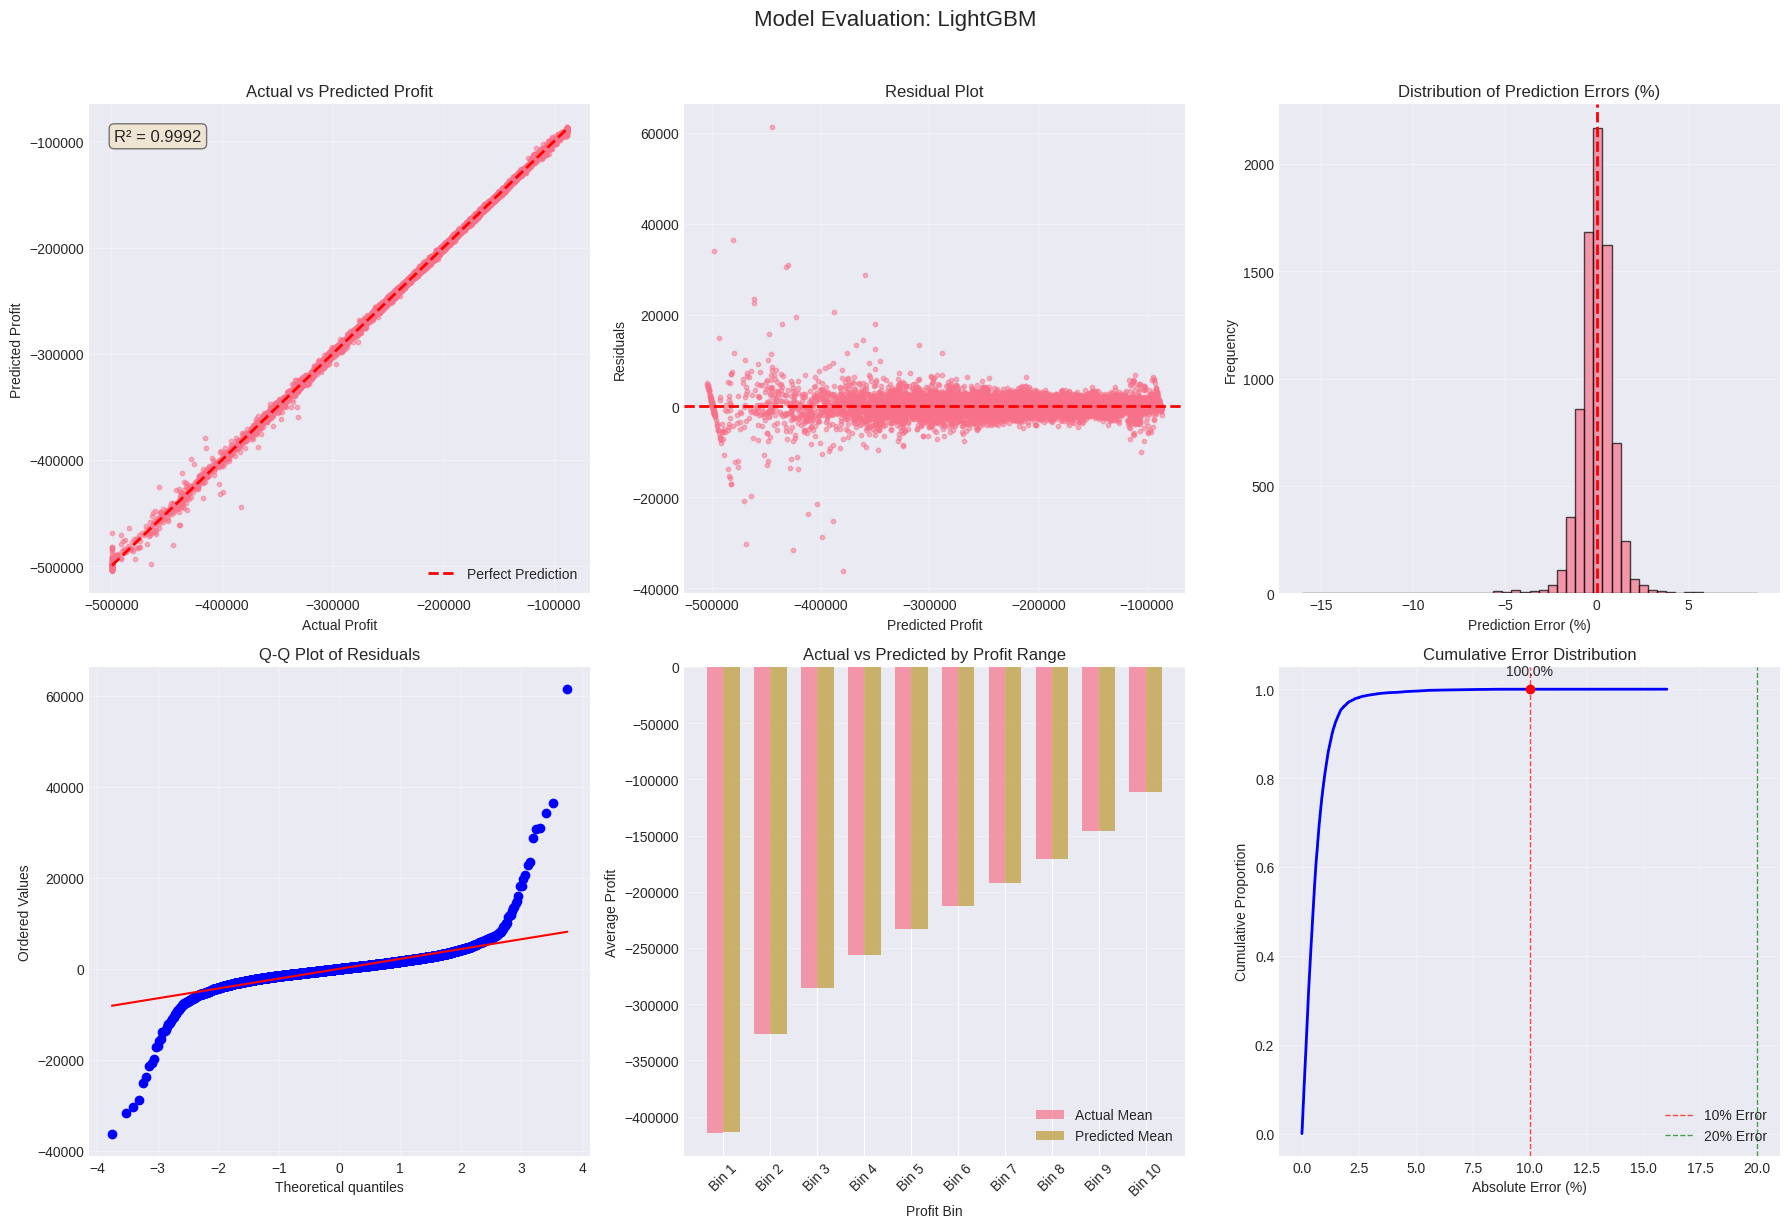


5. Feature Importance Analysis...

Top 10 Most Important Features:
  9. backup_fuel_cost               Importance: 845.0000
 22. revenue_per_km                 Importance: 815.0000
  6. fuel_cost_per_l                Importance: 455.0000
  4. daily_collection               Importance: 293.0000
 21. cost_per_km                    Importance: 125.0000
 20. salary_to_collection_ratio     Importance: 63.0000
  8. driver_salary                  Importance: 51.0000
 12. route_variance                 Importance: 50.0000
  7. maintenance_cost               Importance: 44.0000
 15. year                           Importance: 43.0000

✓ Feature importance plot saved to: best_model_lightgbm/feature_importance.png


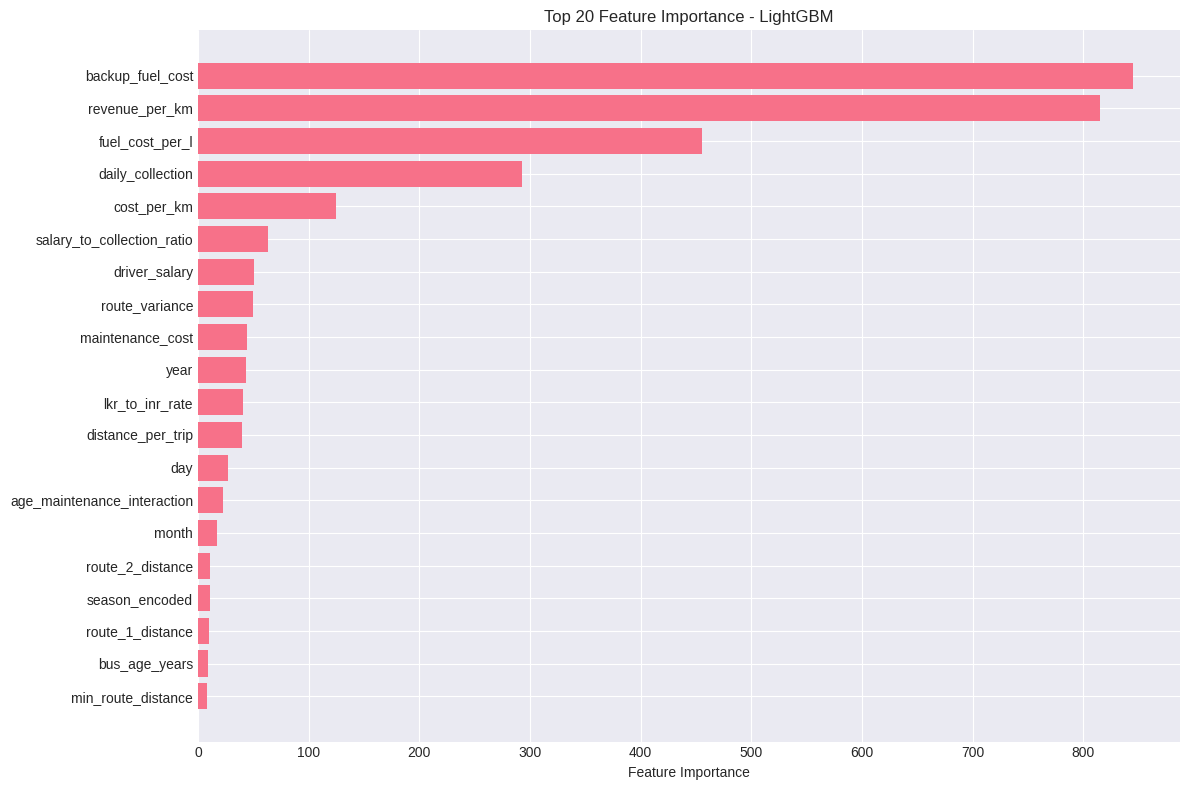

✓ Feature importance data saved to: best_model_lightgbm/feature_importance.csv

6. Model Interpretation...
Generating SHAP values for model interpretation...
✓ SHAP summary plot saved to: best_model_lightgbm/shap_summary.png


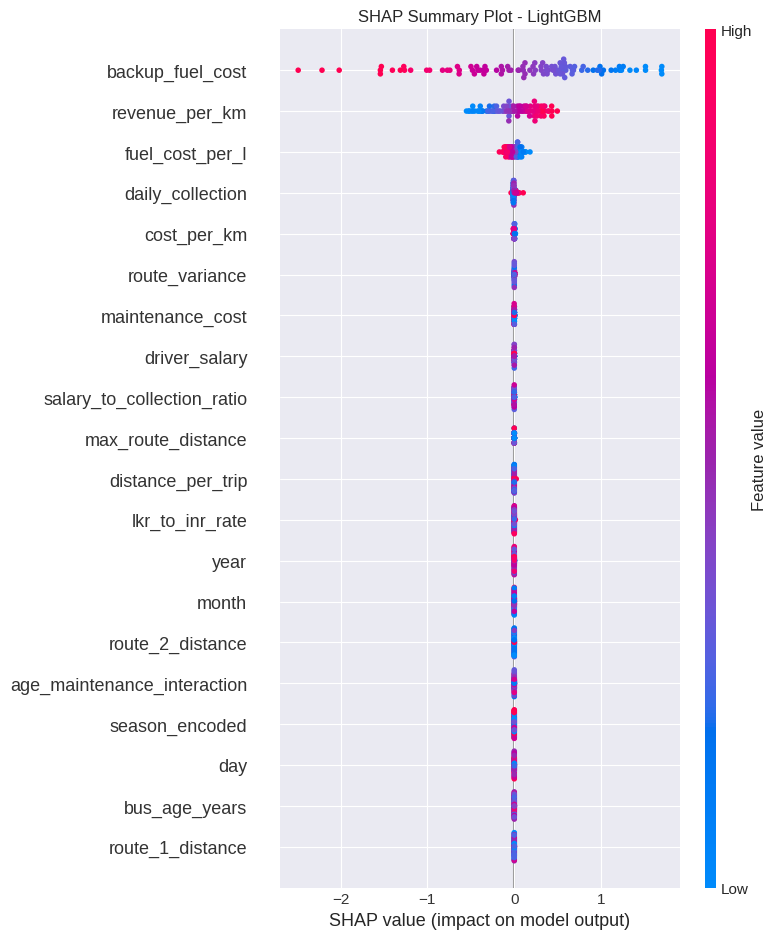

✓ SHAP force plot saved to: best_model_lightgbm/shap_force_plot.png


<Figure size 1000x400 with 0 Axes>

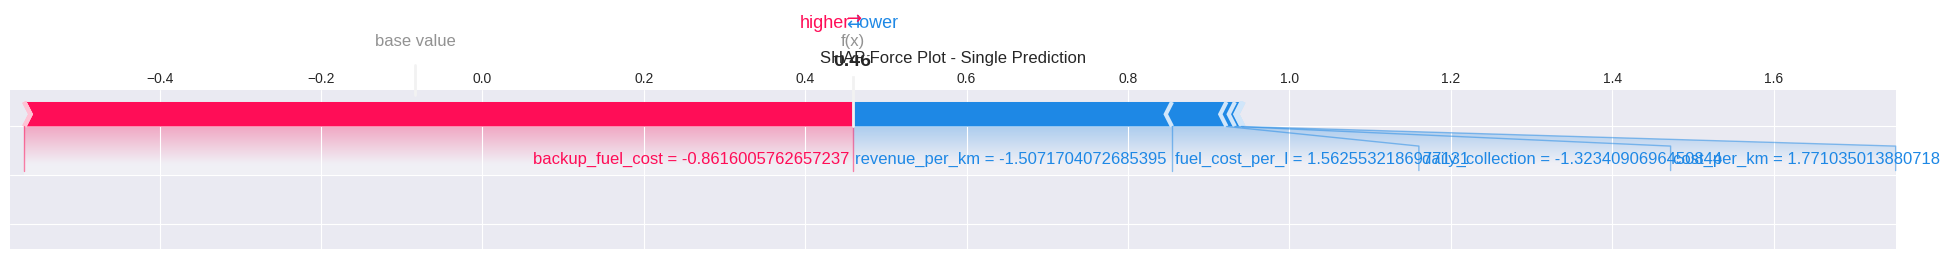


7. Generating final evaluation report...
✓ Evaluation report saved to: best_model_lightgbm/evaluation_report.json

MODEL EVALUATION SUMMARY

Model: LightGBM
Quality: Excellent
R² Score: 0.9992
Recommendation: Production ready

✓ Model evaluation completed successfully!

END OF MODEL EVALUATION SECTION


In [11]:
print("="*80)
print("SECTION 11: MODEL EVALUATION AND INTERPRETATION")
print("="*80)

# 1. Load the best model
print("\n1. Loading the best model...")

# Determine which model to load
model_dirs = [d for d in os.listdir('.') 
             if os.path.isdir(d) and ('ensemble_model' in d or 'tuned_model' in d or 'best_model' in d)]

if not model_dirs:
    print("✗ No model directory found!")
    print("Please run previous sections to train and save a model")
else:
    # Load the most recent model directory
    latest_dir = max(model_dirs, key=os.path.getmtime)
    model_path = os.path.join(latest_dir, 'model.pkl')
    
    if os.path.exists(model_path):
        with open(model_path, 'rb') as f:
            model_components = pickle.load(f)
        
        best_model = model_components['model']
        X_scaler = model_components['X_scaler']
        y_scaler = model_components['y_scaler']
        final_features = model_components['feature_names']
        model_type = model_components['model_type']
        
        print(f"✓ Loaded model: {model_type}")
        print(f"  From directory: {latest_dir}")
        print(f"  Training date: {model_components['training_date']}")
        print(f"  Features used: {len(final_features)}")
    else:
        print(f"✗ Model file not found in {latest_dir}")
        best_model = None

if best_model is not None:
    # 2. Make predictions
    print("\n2. Making predictions for evaluation...")
    
    # Scale test data
    X_test_scaled = X_scaler.transform(X_test)
    
    # Predict
    y_test_pred_scaled = best_model.predict(X_test_scaled)
    y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()
    
    # 3. Comprehensive evaluation metrics
    print("\n3. Calculating comprehensive evaluation metrics...")
    
    # Basic metrics
    r2 = r2_score(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mape = mean_absolute_percentage_error(y_test, y_test_pred)
    
    # Additional metrics
    explained_var = explained_variance_score(y_test, y_test_pred)
    max_err = max_error(y_test, y_test_pred)
    
    # Calculate percentage within tolerance
    tolerance_10pct = np.sum(np.abs(y_test - y_test_pred) / np.abs(y_test) <= 0.1) / len(y_test)
    tolerance_20pct = np.sum(np.abs(y_test - y_test_pred) / np.abs(y_test) <= 0.2) / len(y_test)
    
    print("\n" + "="*60)
    print("COMPREHENSIVE MODEL EVALUATION")
    print("="*60)
    
    print(f"\nModel: {model_type}")
    print(f"Test Set Size: {len(y_test):,} samples")
    
    print("\nPrimary Metrics:")
    print(f"  R² Score:           {r2:.4f}")
    print(f"  RMSE:               {rmse:.2f}")
    print(f"  MAE:                {mae:.2f}")
    print(f"  MAPE:               {mape:.4f}")
    
    print("\nAdditional Metrics:")
    print(f"  Explained Variance: {explained_var:.4f}")
    print(f"  Max Error:          {max_err:.2f}")
    print(f"  Predictions within 10%: {tolerance_10pct:.1%}")
    print(f"  Predictions within 20%: {tolerance_20pct:.1%}")
    
    # 4. Visualizations
    print("\n4. Creating evaluation visualizations...")
    
    fig = plt.figure(figsize=(18, 12))
    
    # 4.1 Actual vs Predicted Scatter Plot
    ax1 = plt.subplot(2, 3, 1)
    ax1.scatter(y_test, y_test_pred, alpha=0.5, s=10)
    ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', lw=2, label='Perfect Prediction')
    ax1.set_xlabel('Actual Profit')
    ax1.set_ylabel('Predicted Profit')
    ax1.set_title('Actual vs Predicted Profit')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add R² text
    ax1.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax1.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 4.2 Residual Plot
    ax2 = plt.subplot(2, 3, 2)
    residuals = y_test - y_test_pred
    ax2.scatter(y_test_pred, residuals, alpha=0.5, s=10)
    ax2.axhline(y=0, color='r', linestyle='--', lw=2)
    ax2.set_xlabel('Predicted Profit')
    ax2.set_ylabel('Residuals')
    ax2.set_title('Residual Plot')
    ax2.grid(True, alpha=0.3)
    
    # 4.3 Error Distribution
    ax3 = plt.subplot(2, 3, 3)
    error_percentage = (residuals / y_test) * 100
    error_percentage = error_percentage[np.isfinite(error_percentage)]  # Remove inf values
    ax3.hist(error_percentage, bins=50, edgecolor='black', alpha=0.7)
    ax3.axvline(x=0, color='r', linestyle='--', lw=2)
    ax3.set_xlabel('Prediction Error (%)')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Distribution of Prediction Errors (%)')
    ax3.grid(True, alpha=0.3)
    
    # 4.4 Q-Q Plot of Residuals
    ax4 = plt.subplot(2, 3, 4)
    stats.probplot(residuals, dist="norm", plot=ax4)
    ax4.set_title('Q-Q Plot of Residuals')
    ax4.grid(True, alpha=0.3)
    
    # 4.5 Prediction Error by Profit Range
    ax5 = plt.subplot(2, 3, 5)
    
    # Create profit bins
    profit_bins = pd.qcut(y_test, q=10, duplicates='drop')
    error_by_bin = pd.DataFrame({
        'Profit Bin': profit_bins,
        'MAE': np.abs(residuals),
        'Actual': y_test,
        'Predicted': y_test_pred
    }).groupby('Profit Bin').agg({
        'MAE': 'mean',
        'Actual': 'mean',
        'Predicted': 'mean'
    }).sort_values('Actual')
    
    x_pos = np.arange(len(error_by_bin))
    width = 0.35
    
    ax5.bar(x_pos - width/2, error_by_bin['Actual'], width, label='Actual Mean', alpha=0.7)
    ax5.bar(x_pos + width/2, error_by_bin['Predicted'], width, label='Predicted Mean', alpha=0.7)
    ax5.set_xlabel('Profit Bin')
    ax5.set_ylabel('Average Profit')
    ax5.set_title('Actual vs Predicted by Profit Range')
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels([f'Bin {i+1}' for i in range(len(error_by_bin))], rotation=45)
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='y')
    
    # 4.6 Cumulative Error Distribution
    ax6 = plt.subplot(2, 3, 6)
    
    # Sort errors by absolute value
    sorted_errors = np.sort(np.abs(error_percentage))
    cumulative_dist = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
    
    ax6.plot(sorted_errors, cumulative_dist, 'b-', lw=2)
    ax6.axvline(x=10, color='r', linestyle='--', lw=1, alpha=0.7, label='10% Error')
    ax6.axvline(x=20, color='g', linestyle='--', lw=1, alpha=0.7, label='20% Error')
    ax6.set_xlabel('Absolute Error (%)')
    ax6.set_ylabel('Cumulative Proportion')
    ax6.set_title('Cumulative Error Distribution')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # Add annotations for error thresholds
    for threshold in [10, 20, 30]:
        idx = np.searchsorted(sorted_errors, threshold)
        if idx < len(sorted_errors):
            proportion = cumulative_dist[idx]
            ax6.plot(threshold, proportion, 'ro')
            ax6.annotate(f'{proportion:.1%}', (threshold, proportion),
                        textcoords="offset points", xytext=(0,10), ha='center')
    
    plt.suptitle(f'Model Evaluation: {model_type}', fontsize=16, y=1.02)
    plt.tight_layout()
    
    # Save the evaluation plot
    eval_plot_path = os.path.join(latest_dir, 'model_evaluation.png')
    plt.savefig(eval_plot_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Evaluation plot saved to: {eval_plot_path}")
    plt.show()
    
    # 5. Feature Importance Analysis
    print("\n5. Feature Importance Analysis...")
    
    if hasattr(best_model, 'feature_importances_'):
        # Get feature importance
        feature_importance = pd.DataFrame({
            'Feature': final_features,
            'Importance': best_model.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        print(f"\nTop 10 Most Important Features:")
        for i, row in feature_importance.head(10).iterrows():
            print(f"{i+1:3d}. {row['Feature']:30} Importance: {row['Importance']:.4f}")
        
        # Plot feature importance
        plt.figure(figsize=(12, 8))
        top_n = min(20, len(feature_importance))
        top_features = feature_importance.head(top_n)
        
        plt.barh(range(len(top_features)), top_features['Importance'])
        plt.yticks(range(len(top_features)), top_features['Feature'])
        plt.xlabel('Feature Importance')
        plt.title(f'Top {top_n} Feature Importance - {model_type}')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        
        # Save feature importance plot
        feat_imp_path = os.path.join(latest_dir, 'feature_importance.png')
        plt.savefig(feat_imp_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Feature importance plot saved to: {feat_imp_path}")
        plt.show()
        
        # Save feature importance data
        feat_imp_csv_path = os.path.join(latest_dir, 'feature_importance.csv')
        feature_importance.to_csv(feat_imp_csv_path, index=False)
        print(f"✓ Feature importance data saved to: {feat_imp_csv_path}")
    
    # 6. Model Interpretation (SHAP values if available)
    print("\n6. Model Interpretation...")
    
    try:
        import shap
        
        print("Generating SHAP values for model interpretation...")
        
        # Create SHAP explainer
        if hasattr(best_model, 'predict_proba'):
            explainer = shap.Explainer(best_model, X_train_scaled[:100])  # Use sample for speed
        else:
            explainer = shap.Explainer(best_model, X_train_scaled[:100])
        
        # Calculate SHAP values
        shap_values = explainer(X_test_scaled[:100])
        
        # Summary plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test_scaled[:100], 
                         feature_names=final_features, show=False)
        plt.title(f'SHAP Summary Plot - {model_type}')
        plt.tight_layout()
        
        # Save SHAP plot
        shap_plot_path = os.path.join(latest_dir, 'shap_summary.png')
        plt.savefig(shap_plot_path, dpi=300, bbox_inches='tight')
        print(f"✓ SHAP summary plot saved to: {shap_plot_path}")
        plt.show()
        
        # Force plot for a single prediction
        plt.figure(figsize=(10, 4))
        shap.force_plot(explainer.expected_value, shap_values[0].values, 
                       X_test_scaled[0], feature_names=final_features, show=False, matplotlib=True)
        plt.title(f'SHAP Force Plot - Single Prediction')
        plt.tight_layout()
        
        # Save force plot
        force_plot_path = os.path.join(latest_dir, 'shap_force_plot.png')
        plt.savefig(force_plot_path, dpi=300, bbox_inches='tight')
        print(f"✓ SHAP force plot saved to: {force_plot_path}")
        plt.show()
        
    except ImportError:
        print("⚠ SHAP not installed. Install with: pip install shap")
    except Exception as e:
        print(f"⚠ Could not generate SHAP values: {str(e)}")
    
    # 7. Save final evaluation report
    print("\n7. Generating final evaluation report...")
    
    evaluation_report = {
        'model_info': {
            'model_type': model_type,
            'training_date': model_components['training_date'],
            'feature_count': len(final_features),
            'train_samples': len(X_train),
            'test_samples': len(X_test)
        },
        'performance_metrics': {
            'r2_score': float(r2),
            'rmse': float(rmse),
            'mae': float(mae),
            'mape': float(mape),
            'explained_variance': float(explained_var),
            'max_error': float(max_err),
            'within_10pct': float(tolerance_10pct),
            'within_20pct': float(tolerance_20pct)
        },
        'model_quality_assessment': {
            'r2_interpretation': 'Excellent' if r2 >= 0.9 else 
                                'Good' if r2 >= 0.7 else 
                                'Fair' if r2 >= 0.5 else 
                                'Poor' if r2 >= 0.3 else 'Very Poor',
            'recommendation': 'Production ready' if r2 >= 0.8 else 
                            'Needs improvement' if r2 >= 0.6 else 
                            'Not suitable for production'
        },
        'top_features': final_features[:20] if len(final_features) > 20 else final_features
    }
    
    # Save report as JSON
    report_path = os.path.join(latest_dir, 'evaluation_report.json')
    with open(report_path, 'w') as f:
        json.dump(evaluation_report, f, indent=4, default=str)
    
    print(f"✓ Evaluation report saved to: {report_path}")
    
    # Print summary
    print("\n" + "="*80)
    print("MODEL EVALUATION SUMMARY")
    print("="*80)
    print(f"\nModel: {model_type}")
    print(f"Quality: {evaluation_report['model_quality_assessment']['r2_interpretation']}")
    print(f"R² Score: {r2:.4f}")
    print(f"Recommendation: {evaluation_report['model_quality_assessment']['recommendation']}")
    print(f"\n✓ Model evaluation completed successfully!")

print("\n" + "="*80)
print("END OF MODEL EVALUATION SECTION")
print("="*80)

# Section 12: Model Input Output Testing

In [12]:
print("="*80)
print("SECTION 12: MODEL INPUT-OUTPUT TESTING")
print("="*80)

# 1. Load the trained model
print("\n1. Loading trained model for inference...")

# Find the latest model directory
model_dirs = [d for d in os.listdir('.') 
             if os.path.isdir(d) and ('ensemble_model' in d or 'tuned_model' in d or 'best_model' in d)]

if not model_dirs:
    print("✗ No trained model found!")
    print("Please run the training sections first.")
else:
    latest_dir = max(model_dirs, key=os.path.getmtime)
    model_path = os.path.join(latest_dir, 'model.pkl')
    
    with open(model_path, 'rb') as f:
        model_components = pickle.load(f)
    
    model = model_components['model']
    X_scaler = model_components['X_scaler']
    y_scaler = model_components['y_scaler']
    feature_names = model_components['feature_names']
    model_type = model_components['model_type']
    
    print(f"✓ Model loaded: {model_type}")
    print(f"  Features required: {len(feature_names)}")
    
    # =====================================================================
    # NEW: MAIN OUTPUT 1 - ASSESSMENT BASED INCOME PREDICTION
    # =====================================================================
    print("\n" + "="*80)
    print("MAIN OUTPUT 1: ASSESSMENT BASED INCOME PREDICTION")
    print("="*80)
    
    def calculate_risk_assessment(profit_prediction, confidence_interval, historical_data):
        """Calculate risk assessment based on profit prediction and historical data"""
        risk_levels = {
            'Very Low Risk': 0.1,   # ≤ 10% uncertainty
            'Low Risk': 0.2,        # ≤ 20% uncertainty
            'Moderate Risk': 0.3,   # ≤ 30% uncertainty
            'High Risk': 0.5,       # ≤ 50% uncertainty
            'Very High Risk': 1.0   # > 50% uncertainty
        }
        
        # Calculate uncertainty percentage
        if confidence_interval and profit_prediction != 0:
            uncertainty_pct = confidence_interval / abs(profit_prediction)
        else:
            uncertainty_pct = 0.3  # Default 30% uncertainty
        
        # Determine risk level
        risk_level = "Very High Risk"
        for level, threshold in risk_levels.items():
            if uncertainty_pct <= threshold:
                risk_level = level
                break
        
        # Calculate confidence score (0-100)
        confidence_score = max(0, min(100, 100 - (uncertainty_pct * 100)))
        
        return {
            'risk_level': risk_level,
            'confidence_score': confidence_score,
            'uncertainty_percentage': uncertainty_pct * 100
        }
    
    def predict_temporal_income(base_daily_profit, time_period, growth_rate=0.05, risk_factor=1.0):
        """Predict income for different time periods with growth and risk adjustment"""
        
        # Define multiplication factors for different time periods
        time_factors = {
            'daily': 1,
            'weekly': 7,
            'monthly': 30,
            'quarterly': 90,
            'annually': 365
        }
        
        if time_period not in time_factors:
            raise ValueError(f"Invalid time period. Choose from: {list(time_factors.keys())}")
        
        # Calculate base income for the period
        base_income = base_daily_profit * time_factors[time_period]
        
        # Apply growth for longer periods (except daily)
        if time_period != 'daily':
            growth_factor = (1 + growth_rate) ** (time_factors[time_period] / 365)
            projected_income = base_income * growth_factor
        else:
            projected_income = base_income
        
        # Apply risk adjustment
        adjusted_income = projected_income * risk_factor
        
        # Calculate intelligent prediction (weighted average of base and projected)
        intelligent_prediction = (base_income * 0.4) + (projected_income * 0.4) + (adjusted_income * 0.2)
        
        return {
            'base_income': base_income,
            'projected_income': projected_income,
            'adjusted_income': adjusted_income,
            'intelligent_prediction': intelligent_prediction,
            'growth_rate_applied': growth_rate if time_period != 'daily' else 0,
            'risk_adjustment_factor': risk_factor
        }
    
    def generate_comprehensive_income_report(daily_input):
        """Generate comprehensive income report for all time periods"""
        
        print("\n" + "="*60)
        print("COMPREHENSIVE INCOME PREDICTION REPORT")
        print("="*60)
        
        # Prepare input
        input_df = pd.DataFrame([daily_input])
        
        # Ensure all required features are present
        missing_features = set(feature_names) - set(input_df.columns)
        for feature in missing_features:
            if feature in X_train.columns:
                input_df[feature] = X_train[feature].median()
            else:
                input_df[feature] = 0
        
        input_df = input_df[feature_names]
        
        # Scale and predict daily profit
        input_scaled = X_scaler.transform(input_df)
        daily_profit_scaled = model.predict(input_scaled)
        daily_profit = y_scaler.inverse_transform(daily_profit_scaled.reshape(-1, 1)).flatten()[0]
        
        # Calculate confidence/uncertainty
        confidence_interval = None
        if hasattr(model, 'estimators_'):
            all_predictions = []
            for estimator in model.estimators_:
                pred = estimator.predict(input_scaled)
                all_predictions.append(pred)
            
            std_prediction = np.std(all_predictions)
            confidence_interval = 1.96 * std_prediction * y_scaler.scale_[0]
        
        # Calculate risk assessment
        historical_std = y_train.std() if 'y_train' in locals() else 100000
        risk_assessment = calculate_risk_assessment(daily_profit, confidence_interval, historical_std)
        
        print(f"\n📊 DAILY INCOME ASSESSMENT:")
        print(f"   Predicted Daily Profit: {daily_profit:,.2f} LKR")
        
        if confidence_interval:
            print(f"   95% Confidence Interval: ±{confidence_interval:,.2f} LKR")
        
        print(f"   Risk Level: {risk_assessment['risk_level']}")
        print(f"   Confidence Score: {risk_assessment['confidence_score']:.1f}%")
        print(f"   Uncertainty: {risk_assessment['uncertainty_percentage']:.1f}%")
        
        # Calculate risk adjustment factor based on risk level
        risk_factors = {
            'Very Low Risk': 1.1,   # 10% premium for low risk
            'Low Risk': 1.05,       # 5% premium
            'Moderate Risk': 1.0,   # No adjustment
            'High Risk': 0.9,       # 10% discount for high risk
            'Very High Risk': 0.8   # 20% discount for very high risk
        }
        risk_factor = risk_factors.get(risk_assessment['risk_level'], 1.0)
        
        print(f"\n⏰ TEMPORAL INCOME PROJECTIONS:")
        print("="*60)
        
        time_periods = ['daily', 'weekly', 'monthly', 'quarterly', 'annually']
        period_names = ['Daily', 'Weekly', 'Monthly', 'Quarterly', 'Annually']
        
        reports = {}
        
        for period, period_name in zip(time_periods, period_names):
            prediction = predict_temporal_income(daily_profit, period, growth_rate=0.05, risk_factor=risk_factor)
            reports[period] = prediction
            
            print(f"\n📅 {period_name.upper()} INCOME:")
            print(f"   Base Income: {prediction['base_income']:,.2f} LKR")
            print(f"   Projected Income (with growth): {prediction['projected_income']:,.2f} LKR")
            print(f"   Risk-Adjusted Income: {prediction['adjusted_income']:,.2f} LKR")
            print(f"   🔥 INTELLIGENT PREDICTION: {prediction['intelligent_prediction']:,.2f} LKR")
            
            if period != 'daily':
                print(f"   Growth Rate Applied: {prediction['growth_rate_applied']*100:.1f}%")
                print(f"   Risk Adjustment Factor: {prediction['risk_adjustment_factor']:.2f}")
        
        # Generate summary table
        print("\n" + "="*60)
        print("SUMMARY TABLE")
        print("="*60)
        print(f"{'Period':<12} {'Intelligent Prediction':<25} {'Risk Level':<15}")
        print("-" * 60)
        
        for period, period_name in zip(time_periods, period_names):
            prediction = reports[period]
            print(f"{period_name:<12} {prediction['intelligent_prediction']:>20,.2f} LKR  {risk_assessment['risk_level']:<15}")
        
        return {
            'daily_profit': daily_profit,
            'risk_assessment': risk_assessment,
            'temporal_predictions': reports,
            'confidence_interval': confidence_interval
        }
    
    # =====================================================================
    # NEW: MAIN OUTPUT 2 - BEST ROUTING SUGGESTION
    # =====================================================================
    print("\n" + "="*80)
    print("MAIN OUTPUT 2: BEST ROUTING SUGGESTION PREDICTION")
    print("="*80)
    
    def find_optimal_route_sequence(route_distances, operational_params):
        """
        Find the optimal route sequence for maximum profit.
        
        Parameters:
        -----------
        route_distances : dict
            Dictionary with route distances {1: distance1, 2: distance2, 3: distance3}
        operational_params : dict
            Other operational parameters
        
        Returns:
        --------
        dict
            Optimal route sequence and profit predictions
        """
        
        print(f"\n📏 ROUTE DISTANCES PROVIDED:")
        for route, distance in route_distances.items():
            print(f"   Route {route}: {distance} km")
        
        # All possible route sequences (permutations of 3 routes)
        all_sequences = [
            [1, 2, 3], [1, 3, 2],
            [2, 1, 3], [2, 3, 1],
            [3, 1, 2], [3, 2, 1]
        ]
        
        sequence_predictions = []
        
        print(f"\n🔍 ANALYZING ALL POSSIBLE ROUTE SEQUENCES ({len(all_sequences)} combinations):")
        print("-" * 80)
        
        for seq in all_sequences:
            # Create input for this sequence
            route_input = operational_params.copy()
            
            # Add route distances in sequence order
            route_input['route_1_distance'] = route_distances[seq[0]]
            route_input['route_2_distance'] = route_distances[seq[1]]
            route_input['route_3_distance'] = route_distances[seq[2]]
            
            # Calculate total distance
            total_distance = sum(route_distances.values())
            route_input['total_distance'] = total_distance
            
            # Calculate route variance (standard deviation of distances)
            distances = list(route_distances.values())
            route_variance = np.std(distances) if len(distances) > 1 else 0
            route_input['route_variance'] = route_variance
            
            # Prepare input DataFrame
            input_df = pd.DataFrame([route_input])
            
            # Ensure all required features are present
            missing_features = set(feature_names) - set(input_df.columns)
            for feature in missing_features:
                if feature in X_train.columns:
                    input_df[feature] = X_train[feature].median()
                else:
                    input_df[feature] = 0
            
            input_df = input_df[feature_names]
            
            # Scale and predict
            input_scaled = X_scaler.transform(input_df)
            profit_scaled = model.predict(input_scaled)
            profit = y_scaler.inverse_transform(profit_scaled.reshape(-1, 1)).flatten()[0]
            
            # Store prediction
            sequence_str = '-'.join(map(str, seq))
            sequence_predictions.append({
                'sequence': sequence_str,
                'route_order': seq,
                'predicted_profit': profit,
                'total_distance': total_distance,
                'route_variance': route_variance
            })
            
            print(f"   Sequence {sequence_str}: {profit:,.2f} LKR")
        
        # Find best sequence
        best_sequence = max(sequence_predictions, key=lambda x: x['predicted_profit'])
        worst_sequence = min(sequence_predictions, key=lambda x: x['predicted_profit'])
        
        print("\n" + "="*80)
        print("🏆 OPTIMAL ROUTING RECOMMENDATION")
        print("="*80)
        
        print(f"\n✓ BEST ROUTE SEQUENCE: {best_sequence['sequence']}")
        print(f"   Predicted Profit: {best_sequence['predicted_profit']:,.2f} LKR")
        print(f"   Total Distance: {best_sequence['total_distance']} km")
        print(f"   Route Variance: {best_sequence['route_variance']:.2f}")
        
        print(f"\n✗ WORST ROUTE SEQUENCE: {worst_sequence['sequence']}")
        print(f"   Predicted Profit: {worst_sequence['predicted_profit']:,.2f} LKR")
        print(f"   Performance Difference: {best_sequence['predicted_profit'] - worst_sequence['predicted_profit']:,.2f} LKR")
        
        # Calculate efficiency metrics
        avg_profit = np.mean([s['predicted_profit'] for s in sequence_predictions])
        profit_range = best_sequence['predicted_profit'] - worst_sequence['predicted_profit']
        
        print(f"\n📈 SEQUENCE PERFORMANCE ANALYSIS:")
        print(f"   Average Profit across all sequences: {avg_profit:,.2f} LKR")
        print(f"   Profit Range: {profit_range:,.2f} LKR")
        print(f"   Best sequence outperforms average by: {best_sequence['predicted_profit'] - avg_profit:,.2f} LKR")
        
        # Recommendations based on distances
        print(f"\n💡 INTELLIGENT RECOMMENDATIONS:")
        
        # Check if distances suggest short or long route operations
        max_distance = max(route_distances.values())
        total_daily_distance = sum(route_distances.values())
        
        if total_daily_distance <= 150:  # Short distance operations
            print("   → SHORT-DISTANCE OPERATIONS DETECTED")
            print("   → Can complete all 3 routes in one day")
            print("   → Focus on passenger density and quick turnarounds")
        elif total_daily_distance <= 300:  # Medium distance
            print("   → MEDIUM-DISTANCE OPERATIONS DETECTED")
            print("   → May require 1-2 days to complete all routes")
            print("   → Balance between distance and operational efficiency")
        else:  # Long distance
            print("   → LONG-DISTANCE OPERATIONS DETECTED")
            print("   → Will require 2-3 days to complete all routes")
            print("   → Focus on fuel efficiency and overnight scheduling")
        
        # Additional recommendations based on route variance
        if best_sequence['route_variance'] > 50:
            print("   → HIGH ROUTE VARIANCE DETECTED")
            print("   → Consider balancing route distances for better efficiency")
        else:
            print("   → ROUTE DISTANCES ARE WELL-BALANCED")
            print("   → Good for consistent operations")
        
        return {
            'best_sequence': best_sequence,
            'worst_sequence': worst_sequence,
            'all_predictions': sequence_predictions,
            'recommendations': {
                'operation_type': 'short' if total_daily_distance <= 150 else 'medium' if total_daily_distance <= 300 else 'long',
                'estimated_days_needed': 1 if total_daily_distance <= 150 else 2 if total_daily_distance <= 300 else 3,
                'route_balance': 'high_variance' if best_sequence['route_variance'] > 50 else 'balanced'
            }
        }
    
        # =====================================================================
    # INTERACTIVE TESTING WITH BOTH OUTPUTS
    # =====================================================================
    print("\n" + "="*80)
    print("INTERACTIVE MODEL TESTING WITH MAIN OUTPUTS")
    print("="*80)
    
    def test_comprehensive_system():
        """Test the comprehensive system with both main outputs"""
        
        print("\nSelect testing mode:")
        print("1. Income Prediction Assessment (Temporal Analysis)")
        print("2. Optimal Routing Suggestion")
        print("3. Complete Analysis (Both)")
        
        try:
            choice = int(input("\nEnter choice (1-3): "))
        except:
            print("Invalid choice. Using default: Complete Analysis")
            choice = 3
        
        # Common operational parameters
        print("\n📝 ENTER OPERATIONAL PARAMETERS:")
        
        operational_params = {}
        
        # Get key parameters
        key_params = {
            'daily_collection': ('Daily Collection (LKR)', 175000),
            'trips_count': ('Number of Trips', 2),
            'fuel_cost_per_l': ('Fuel Cost per Liter (LKR)', 350.0),
            'maintenance_cost': ('Maintenance Cost (LKR)', 700),
            'driver_salary': ('Driver Salary (LKR)', 2100),
            'conductor_salary': ('Conductor Salary (LKR)', 1600),
            'bus_age_years': ('Bus Age (years)', 5),
            'deadweight_factor': ('Deadweight Factor (0-1)', 0.1)
        }
        
        for param, (label, default) in key_params.items():
            if param in feature_names:
                try:
                    value = input(f"{label} (default: {default}): ")
                    if value.strip() == '':
                        operational_params[param] = default
                    else:
                        operational_params[param] = float(value)
                except:
                    operational_params[param] = default
        
        # Fill missing features with defaults
        for feature in feature_names:
            if feature not in operational_params:
                if feature in X_train.columns:
                    operational_params[feature] = X_train[feature].median()
                else:
                    operational_params[feature] = 0
        
        if choice in [1, 3]:
            print("\n" + "="*80)
            print("RUNNING INCOME PREDICTION ASSESSMENT...")
            print("="*80)
            
            income_report = generate_comprehensive_income_report(operational_params)
            
            # Save report
            report_path = os.path.join(latest_dir, 'income_prediction_report.json')
            with open(report_path, 'w') as f:
                # Convert numpy types for JSON serialization
                serializable_report = {
                    'daily_profit': float(income_report['daily_profit']),
                    'risk_assessment': income_report['risk_assessment'],
                    'confidence_interval': float(income_report['confidence_interval']) if income_report['confidence_interval'] else None,
                    'temporal_predictions': {
                        period: {k: float(v) if isinstance(v, (np.float32, np.float64, np.int32, np.int64)) else v 
                               for k, v in pred.items()}
                        for period, pred in income_report['temporal_predictions'].items()
                    }
                }
                json.dump(serializable_report, f, indent=4)
            
            print(f"\n✓ Income prediction report saved to: {report_path}")
        
        if choice in [2, 3]:
            print("\n" + "="*80)
            print("RUNNING OPTIMAL ROUTING ANALYSIS...")
            print("="*80)
            
            # Get route distances
            route_distances = {}
            print("\n📏 ENTER ROUTE DISTANCES (5-300 km each):")
            
            for route_num in [1, 2, 3]:
                while True:
                    try:
                        distance = float(input(f"Route {route_num} distance (km, default: {100 if route_num == 1 else 80 if route_num == 2 else 120}): ") 
                                      or (100 if route_num == 1 else 80 if route_num == 2 else 120))
                        if 5 <= distance <= 300:
                            route_distances[route_num] = distance
                            break
                        else:
                            print("Distance must be between 5 and 300 km")
                    except:
                        print("Invalid input. Using default.")
                        route_distances[route_num] = 100 if route_num == 1 else 80 if route_num == 2 else 120
                        break
            
            routing_analysis = find_optimal_route_sequence(route_distances, operational_params)
            
            # Save routing analysis
            routing_path = os.path.join(latest_dir, 'routing_analysis.json')
            with open(routing_path, 'w') as f:
                serializable_routing = {
                    'best_sequence': {
                        'sequence': routing_analysis['best_sequence']['sequence'],
                        'predicted_profit': float(routing_analysis['best_sequence']['predicted_profit']),
                        'total_distance': float(routing_analysis['best_sequence']['total_distance']),
                        'route_variance': float(routing_analysis['best_sequence']['route_variance'])
                    },
                    'worst_sequence': {
                        'sequence': routing_analysis['worst_sequence']['sequence'],
                        'predicted_profit': float(routing_analysis['worst_sequence']['predicted_profit']),
                        'total_distance': float(routing_analysis['worst_sequence']['total_distance']),
                        'route_variance': float(routing_analysis['worst_sequence']['route_variance'])
                    },
                    'recommendations': routing_analysis['recommendations'],
                    'all_predictions': [
                        {
                            'sequence': p['sequence'],
                            'predicted_profit': float(p['predicted_profit']),
                            'total_distance': float(p['total_distance']),
                            'route_variance': float(p['route_variance'])
                        }
                        for p in routing_analysis['all_predictions']
                    ]
                }
                json.dump(serializable_routing, f, indent=4)
            
            print(f"\n✓ Routing analysis saved to: {routing_path}")
        
        print("\n" + "="*80)
        print("ANALYSIS COMPLETED SUCCESSFULLY!")
        print("="*80)
    
    # =====================================================================
    # EXAMPLE USAGE
    # =====================================================================
    print("\n" + "="*80)
    print("QUICK DEMONSTRATION")
    print("="*80)
    
    # Example 1: Quick income prediction with sample data
    print("\n📊 EXAMPLE 1: QUICK INCOME PREDICTION")
    
    sample_daily_input = {}
    for feature in feature_names:
        if feature in X_train.columns:
            sample_daily_input[feature] = X_train[feature].median()
        else:
            sample_daily_input[feature] = 0
    
    # Set some key parameters for the example
    sample_daily_input['daily_collection'] = 180000
    sample_daily_input['total_distance'] = 350
    sample_daily_input['fuel_cost_per_l'] = 360
    sample_daily_input['trips_count'] = 3
    
    quick_income = generate_comprehensive_income_report(sample_daily_input)
    
    # Example 2: Quick routing suggestion
    print("\n\n🗺️ EXAMPLE 2: QUICK ROUTING SUGGESTION")
    
    example_routes = {1: 120, 2: 80, 3: 150}  # Route distances in km
    example_operational = sample_daily_input.copy()
    
    quick_routing = find_optimal_route_sequence(example_routes, example_operational)
    
    # =====================================================================
    # INTERACTIVE MENU
    # =====================================================================
    print("\n" + "="*80)
    print("MAIN MENU - SELECT ANALYSIS TYPE")
    print("="*80)
    
    print("\nAvailable analysis types:")
    print("1. Income Prediction Assessment")
    print("2. Optimal Routing Suggestion")
    print("3. Complete Analysis (Both)")
    print("4. Batch Analysis (Multiple scenarios)")
    print("5. Exit")
    
    while True:
        try:
            menu_choice = int(input("\nSelect option (1-5): "))
            
            if menu_choice == 1:
                print("\n" + "="*80)
                print("INCOME PREDICTION ASSESSMENT SELECTED")
                print("="*80)
                
                # Run income prediction
                income_report = generate_comprehensive_income_report(sample_daily_input)
                
                # Ask if user wants to customize
                customize = input("\nCustomize parameters? (y/n): ").lower()
                if customize == 'y':
                    test_comprehensive_system()
                
            elif menu_choice == 2:
                print("\n" + "="*80)
                print("OPTIMAL ROUTING SUGGESTION SELECTED")
                print("="*80)
                
                # Get route distances from user
                route_distances = {}
                print("\nEnter route distances:")
                for i in [1, 2, 3]:
                    while True:
                        try:
                            dist = float(input(f"Route {i} distance (km): "))
                            if 5 <= dist <= 300:
                                route_distances[i] = dist
                                break
                            else:
                                print("Distance must be between 5-300 km")
                        except:
                            print("Invalid input")
                
                # Run routing analysis
                routing_result = find_optimal_route_sequence(route_distances, sample_daily_input)
                
                # Ask if user wants to customize operational parameters
                customize = input("\nCustomize operational parameters? (y/n): ").lower()
                if customize == 'y':
                    test_comprehensive_system()
                
            elif menu_choice == 3:
                print("\n" + "="*80)
                print("COMPLETE ANALYSIS SELECTED")
                print("="*80)
                test_comprehensive_system()
                
            elif menu_choice == 4:
                print("\n" + "="*80)
                print("BATCH ANALYSIS")
                print("="*80)
                
                try:
                    n_scenarios = int(input("Number of scenarios to analyze: "))
                    if n_scenarios > 10:
                        print("Limiting to 10 scenarios for performance")
                        n_scenarios = 10
                    
                    batch_results = []
                    
                    for i in range(n_scenarios):
                        print(f"\n📋 Scenario {i+1}/{n_scenarios}")
                        
                        # Generate random route distances
                        route_dists = {
                            1: np.random.randint(50, 200),
                            2: np.random.randint(50, 200),
                            3: np.random.randint(50, 200)
                        }
                        
                        # Generate random operational parameters
                        ops_params = sample_daily_input.copy()
                        ops_params['daily_collection'] = np.random.randint(100000, 300000)
                        ops_params['fuel_cost_per_l'] = np.random.uniform(320, 380)
                        ops_params['trips_count'] = np.random.randint(1, 4)
                        
                        # Get routing suggestion
                        routing = find_optimal_route_sequence(route_dists, ops_params)
                        
                        batch_results.append({
                            'scenario': i+1,
                            'route_distances': route_dists,
                            'best_sequence': routing['best_sequence']['sequence'],
                            'predicted_profit': routing['best_sequence']['predicted_profit']
                        })
                    
                    # Display batch summary
                    print("\n" + "="*80)
                    print("BATCH ANALYSIS SUMMARY")
                    print("="*80)
                    
                    for result in batch_results:
                        print(f"\nScenario {result['scenario']}:")
                        print(f"  Routes: {result['route_distances']}")
                        print(f"  Best Sequence: {result['best_sequence']}")
                        print(f"  Predicted Profit: {result['predicted_profit']:,.2f} LKR")
                    
                except:
                    print("Error in batch analysis")
                
            elif menu_choice == 5:
                print("\nExiting...")
                break
                
            else:
                print("Invalid choice. Please select 1-5.")
                
        except ValueError:
            print("Please enter a valid number")
    
    print("\n✓ Main outputs generated successfully!")

print("\n" + "="*80)
print("END OF MODEL TESTING SECTION")
print("="*80)

SECTION 12: MODEL INPUT-OUTPUT TESTING

1. Loading trained model for inference...
✓ Model loaded: LightGBM
  Features required: 30

MAIN OUTPUT 1: ASSESSMENT BASED INCOME PREDICTION

MAIN OUTPUT 2: BEST ROUTING SUGGESTION PREDICTION

INTERACTIVE MODEL TESTING WITH MAIN OUTPUTS

QUICK DEMONSTRATION

📊 EXAMPLE 1: QUICK INCOME PREDICTION

COMPREHENSIVE INCOME PREDICTION REPORT

📊 DAILY INCOME ASSESSMENT:
   Predicted Daily Profit: -226,596.22 LKR
   Risk Level: Moderate Risk
   Confidence Score: 70.0%
   Uncertainty: 30.0%

⏰ TEMPORAL INCOME PROJECTIONS:

📅 DAILY INCOME:
   Base Income: -226,596.22 LKR
   Projected Income (with growth): -226,596.22 LKR
   Risk-Adjusted Income: -226,596.22 LKR
   🔥 INTELLIGENT PREDICTION: -226,596.22 LKR

📅 WEEKLY INCOME:
   Base Income: -1,586,173.51 LKR
   Projected Income (with growth): -1,587,658.39 LKR
   Risk-Adjusted Income: -1,587,658.39 LKR
   🔥 INTELLIGENT PREDICTION: -1,587,064.44 LKR
   Growth Rate Applied: 5.0%
   Risk Adjustment Factor: 1.00



Select option (1-5):  3



COMPLETE ANALYSIS SELECTED

Select testing mode:
1. Income Prediction Assessment (Temporal Analysis)
2. Optimal Routing Suggestion
3. Complete Analysis (Both)



Enter choice (1-3):  3



📝 ENTER OPERATIONAL PARAMETERS:


...


RUNNING INCOME PREDICTION ASSESSMENT...

COMPREHENSIVE INCOME PREDICTION REPORT

📊 DAILY INCOME ASSESSMENT:
   Predicted Daily Profit: -225,458.12 LKR
   Risk Level: Moderate Risk
   Confidence Score: 70.0%
   Uncertainty: 30.0%

⏰ TEMPORAL INCOME PROJECTIONS:

📅 DAILY INCOME:
   Base Income: -225,458.12 LKR
   Projected Income (with growth): -225,458.12 LKR
   Risk-Adjusted Income: -225,458.12 LKR
   🔥 INTELLIGENT PREDICTION: -225,458.12 LKR

📅 WEEKLY INCOME:
   Base Income: -1,578,206.81 LKR
   Projected Income (with growth): -1,579,684.23 LKR
   Risk-Adjusted Income: -1,579,684.23 LKR
   🔥 INTELLIGENT PREDICTION: -1,579,093.26 LKR
   Growth Rate Applied: 5.0%
   Risk Adjustment Factor: 1.00

📅 MONTHLY INCOME:
   Base Income: -6,763,743.47 LKR
   Projected Income (with growth): -6,790,921.56 LKR
   Risk-Adjusted Income: -6,790,921.56 LKR
   🔥 INTELLIGENT PREDICTION: -6,780,050.32 LKR
   Growth Rate Applied: 5.0%
   Risk Adjustment Factor: 1.00

📅 QUARTERLY INCOME:
   Base Income: -2

Route 1 distance (km, default: 100):  
Route 2 distance (km, default: 80):  
Route 3 distance (km, default: 120):  



📏 ROUTE DISTANCES PROVIDED:
   Route 1: 100.0 km
   Route 2: 80.0 km
   Route 3: 120.0 km

🔍 ANALYZING ALL POSSIBLE ROUTE SEQUENCES (6 combinations):
--------------------------------------------------------------------------------
   Sequence 1-2-3: -225,458.12 LKR
   Sequence 1-3-2: -225,458.12 LKR
   Sequence 2-1-3: -225,458.12 LKR
   Sequence 2-3-1: -225,458.12 LKR
   Sequence 3-1-2: -225,458.12 LKR
   Sequence 3-2-1: -225,458.12 LKR

🏆 OPTIMAL ROUTING RECOMMENDATION

✓ BEST ROUTE SEQUENCE: 1-2-3
   Predicted Profit: -225,458.12 LKR
   Total Distance: 300.0 km
   Route Variance: 16.33

✗ WORST ROUTE SEQUENCE: 1-2-3
   Predicted Profit: -225,458.12 LKR
   Performance Difference: 0.00 LKR

📈 SEQUENCE PERFORMANCE ANALYSIS:
   Average Profit across all sequences: -225,458.12 LKR
   Profit Range: 0.00 LKR
   Best sequence outperforms average by: 0.00 LKR

💡 INTELLIGENT RECOMMENDATIONS:
   → MEDIUM-DISTANCE OPERATIONS DETECTED
   → May require 1-2 days to complete all routes
   → Balance


Select option (1-5):  5



Exiting...

✓ Main outputs generated successfully!

END OF MODEL TESTING SECTION


# Section 13: Collecting All Used Library Versions

In [13]:
print("="*80)
print("SECTION 13: LIBRARY VERSIONS COLLECTION")
print("="*80)

import sys
import subprocess
import pkg_resources

print("\nCollecting library versions...")

# Get Python version
print(f"\nPython Version: {sys.version}")

# Get installed packages
installed_packages = []
for dist in pkg_resources.working_set:
    installed_packages.append(f"{dist.key}=={dist.version}")

# Sort alphabetically
installed_packages.sort()

# Filter for relevant ML/data science packages
relevant_packages = [
    'numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn',
    'scipy', 'statsmodels', 'xgboost', 'lightgbm', 'shap'
]

print("\nRelevant package versions:")
print("-" * 50)

for package in relevant_packages:
    for installed in installed_packages:
        if installed.startswith(package):
            print(installed)
            break

# Create requirements.txt
print("\nCreating requirements.txt file...")

# Get all packages used in this project
all_used_packages = [
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'scipy',
    'statsmodels',
    'xgboost',
    'lightgbm',
    'shap',
    'joblib'
]

requirements_content = []
for package in all_used_packages:
    for installed in installed_packages:
        if installed.startswith(package):
            requirements_content.append(installed)
            break

# Add Python version
requirements_content.insert(0, f"# Python {sys.version.split()[0]}")

# Write to file
with open('requirements.txt', 'w') as f:
    f.write('\n'.join(requirements_content))

print(f"✓ requirements.txt created with {len(requirements_content)} packages")
print("\nContents of requirements.txt:")
print("-" * 50)
print('\n'.join(requirements_content))

# Also create a simplified version for deployment
simple_requirements = [
    f"numpy=={pkg_resources.get_distribution('numpy').version}",
    f"pandas=={pkg_resources.get_distribution('pandas').version}",
    f"scikit-learn=={pkg_resources.get_distribution('scikit-learn').version}",
    f"xgboost=={pkg_resources.get_distribution('xgboost').version}" if 'xgboost' in [pkg.key for pkg in pkg_resources.working_set] else "# xgboost not installed",
    f"lightgbm=={pkg_resources.get_distribution('lightgbm').version}" if 'lightgbm' in [pkg.key for pkg in pkg_resources.working_set] else "# lightgbm not installed",
]

with open('requirements_simple.txt', 'w') as f:
    f.write('\n'.join(simple_requirements))

print(f"\n✓ Simplified requirements saved to requirements_simple.txt")

# Create environment.yml for conda
conda_content = f"""name: bus-profit-prediction
channels:
  - conda-forge
  - defaults
dependencies:
  - python={sys.version.split()[0]}
  - numpy={pkg_resources.get_distribution('numpy').version}
  - pandas={pkg_resources.get_distribution('pandas').version}
  - scikit-learn={pkg_resources.get_distribution('scikit-learn').version}
  - matplotlib={pkg_resources.get_distribution('matplotlib').version}
  - seaborn={pkg_resources.get_distribution('seaborn').version}
  - pip
  - pip:
"""

# Add pip packages
for package in ['xgboost', 'lightgbm', 'shap']:
    try:
        version = pkg_resources.get_distribution(package).version
        conda_content += f"    - {package}=={version}\n"
    except:
        conda_content += f"    - {package}\n"

with open('environment.yml', 'w') as f:
    f.write(conda_content)

print(f"✓ Conda environment file saved to environment.yml")

print("\n✓ Library versions collection completed!")

SECTION 13: LIBRARY VERSIONS COLLECTION


Python Version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]

Relevant package versions:
--------------------------------------------------
numpy==2.0.2
pandas-datareader==0.10.0
matplotlib-inline==0.1.7
seaborn==0.13.2
scikit-learn-intelex==2025.10.0
scipy==1.15.3
statsmodels==0.14.5
xgboost==3.1.0
lightgbm==4.6.0
shap==0.49.1

Creating requirements.txt file...
✓ requirements.txt created with 12 packages

Contents of requirements.txt:
--------------------------------------------------
# Python 3.12.12
numpy==2.0.2
pandas-datareader==0.10.0
matplotlib-inline==0.1.7
seaborn==0.13.2
scikit-learn-intelex==2025.10.0
scipy==1.15.3
statsmodels==0.14.5
xgboost==3.1.0
lightgbm==4.6.0
shap==0.49.1
joblib==1.5.3

✓ Simplified requirements saved to requirements_simple.txt
✓ Conda environment file saved to environment.yml

✓ Library versions collection completed!


# Section 14: Model Deployment Support Code

In [14]:
print("="*80)
print("SECTION 14: MODEL DEPLOYMENT SUPPORT CODE")
print("="*80)

print("\nThis section provides code snippets for deploying the trained model.")
print("The code is provided as non-executable examples for different deployment scenarios.\n")

# 1. Basic Model Loading and Prediction Function
deployment_code_1 = '''
# ============================================================================
# DEPLOYMENT MODULE: Basic Model Loading and Prediction
# ============================================================================

import pickle
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

class BusProfitPredictor:
    """
    A class to load and use the trained bus profit prediction model.
    """
    
    def __init__(self, model_path='trained_model/model.pkl'):
        """
        Initialize the predictor by loading the trained model.
        
        Parameters:
        -----------
        model_path : str
            Path to the saved model pickle file
        """
        self.model_path = model_path
        self.model = None
        self.X_scaler = None
        self.y_scaler = None
        self.feature_names = None
        
        self.load_model()
    
    def load_model(self):
        """Load the trained model and associated components."""
        try:
            with open(self.model_path, 'rb') as f:
                model_components = pickle.load(f)
            
            self.model = model_components['model']
            self.X_scaler = model_components['X_scaler']
            self.y_scaler = model_components['y_scaler']
            self.feature_names = model_components['feature_names']
            
            print(f"✓ Model loaded successfully")
            print(f"  Model type: {model_components.get('model_type', 'Unknown')}")
            print(f"  Features: {len(self.feature_names)}")
            
        except FileNotFoundError:
            print(f"✗ Model file not found at {self.model_path}")
            raise
        except Exception as e:
            print(f"✗ Error loading model: {str(e)}")
            raise
    
    def prepare_input(self, input_data):
        """
        Prepare input data for prediction.
        
        Parameters:
        -----------
        input_data : dict or pandas.DataFrame
            Input data with feature values
        
        Returns:
        --------
        pandas.DataFrame
            Prepared input data with all required features
        """
        # Convert dict to DataFrame if needed
        if isinstance(input_data, dict):
            input_df = pd.DataFrame([input_data])
        else:
            input_df = input_data.copy()
        
        # Ensure all required features are present
        missing_features = set(self.feature_names) - set(input_df.columns)
        
        if missing_features:
            print(f"⚠ Missing features detected: {missing_features}")
            print("  Filling with median values...")
            
            # Load training statistics if available
            try:
                with open('trained_model/training_stats.pkl', 'rb') as f:
                    training_stats = pickle.load(f)
                
                for feature in missing_features:
                    if feature in training_stats:
                        input_df[feature] = training_stats[feature]['median']
                    else:
                        input_df[feature] = 0
            except:
                # Use default values if training stats not available
                default_values = {
                    'daily_collection': 150000,
                    'total_distance': 350,
                    'fuel_cost_per_l': 350.0,
                    'trips_count': 2,
                    'bus_age_years': 5,
                    'route_variance': 45.0,
                    'maintenance_cost': 700,
                    'driver_salary': 2100,
                    'conductor_salary': 1600,
                    'deadweight_factor': 0.1
                }
                
                for feature in missing_features:
                    input_df[feature] = default_values.get(feature, 0)
        
        # Reorder columns to match training order
        input_df = input_df[self.feature_names]
        
        return input_df
    
    def predict(self, input_data):
        """
        Make a profit prediction.
        
        Parameters:
        -----------
        input_data : dict or pandas.DataFrame
            Input data with feature values
        
        Returns:
        --------
        dict
            Prediction results including profit and confidence
        """
        # Prepare input
        prepared_input = self.prepare_input(input_data)
        
        # Scale input
        input_scaled = self.X_scaler.transform(prepared_input)
        
        # Make prediction
        prediction_scaled = self.model.predict(input_scaled)
        
        # Inverse transform to original scale
        prediction = self.y_scaler.inverse_transform(
            prediction_scaled.reshape(-1, 1)
        ).flatten()[0]
        
        # Calculate confidence/uncertainty if available
        confidence_info = self._calculate_confidence(input_scaled, prediction_scaled)
        
        # Prepare result
        result = {
            'predicted_profit': float(prediction),
            'confidence_interval': confidence_info.get('confidence_interval'),
            'uncertainty_percentage': confidence_info.get('uncertainty_percentage'),
            'input_features_used': len(self.feature_names)
        }
        
        return result
    
    def _calculate_confidence(self, input_scaled, prediction_scaled):
        """
        Calculate confidence interval for the prediction.
        
        Parameters:
        -----------
        input_scaled : numpy.ndarray
            Scaled input features
        prediction_scaled : numpy.ndarray
            Scaled prediction
        
        Returns:
        --------
        dict
            Confidence information
        """
        confidence_info = {}
        
        # For ensemble models, calculate standard deviation
        if hasattr(self.model, 'estimators_'):
            all_predictions = []
            for estimator in self.model.estimators_:
                pred = estimator.predict(input_scaled)
                all_predictions.append(pred)
            
            all_predictions = np.array(all_predictions)
            std_prediction = np.std(all_predictions)
            
            # Convert to original scale
            std_original = std_prediction * self.y_scaler.scale_[0]
            
            # 95% confidence interval
            confidence_interval = 1.96 * std_original
            
            confidence_info = {
                'confidence_interval': float(confidence_interval),
                'uncertainty_percentage': float(std_original / abs(prediction_scaled[0]) * 100)
            }
        
        return confidence_info
    
    def batch_predict(self, input_data_list):
        """
        Make predictions for multiple inputs.
        
        Parameters:
        -----------
        input_data_list : list of dict or pandas.DataFrame
            List of input data
        
        Returns:
        --------
        list of dict
            List of prediction results
        """
        results = []
        for input_data in input_data_list:
            result = self.predict(input_data)
            results.append(result)
        
        return results


# Example usage
if __name__ == "__main__":
    # Initialize predictor
    predictor = BusProfitPredictor('trained_model/model.pkl')
    
    # Example input
    example_input = {
        'daily_collection': 175000,
        'total_distance': 400,
        'fuel_cost_per_l': 360.5,
        'trips_count': 3,
        'bus_age_years': 7,
        'route_variance': 50.2,
        'maintenance_cost': 750,
        'driver_salary': 2200,
        'conductor_salary': 1650,
        'deadweight_factor': 0.05
    }
    
    # Make prediction
    result = predictor.predict(example_input)
    
    print("\\n📊 Prediction Result:")
    print(f"Predicted Profit: {result['predicted_profit']:,.2f} LKR")
    
    if result['confidence_interval']:
        print(f"95% Confidence Interval: ±{result['confidence_interval']:,.2f} LKR")
        print(f"Uncertainty: {result['uncertainty_percentage']:.1f}%")
'''

print("=" * 60)
print("DEPLOYMENT CODE 1: Basic Model Loading and Prediction")
print("=" * 60)
print(deployment_code_1)

# 2. FastAPI Web Service Deployment
deployment_code_2 = '''
# ============================================================================
# DEPLOYMENT MODULE: FastAPI Web Service
# ============================================================================

"""
FastAPI application for bus profit prediction API.
Install dependencies: pip install fastapi uvicorn pydantic
Run: uvicorn api:app --reload --host 0.0.0.0 --port 8000
"""

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import List, Optional
import pickle
import pandas as pd
import numpy as np
from datetime import datetime
import uvicorn

# Import the predictor class
from predictor import BusProfitPredictor

# Initialize FastAPI app
app = FastAPI(
    title="Bus Profit Prediction API",
    description="API for predicting bus operation profits in Sri Lanka",
    version="1.0.0",
    docs_url="/docs",
    redoc_url="/redoc"
)

# Initialize predictor
predictor = None

class PredictionInput(BaseModel):
    """Input data model for single prediction."""
    daily_collection: float = Field(..., description="Daily ticket collection in LKR")
    total_distance: float = Field(..., description="Total distance traveled in km")
    fuel_cost_per_l: float = Field(..., description="Fuel cost per liter in LKR")
    trips_count: int = Field(..., description="Number of trips")
    bus_age_years: int = Field(..., description="Bus age in years")
    route_variance: float = Field(..., description="Route variance metric")
    maintenance_cost: float = Field(..., description="Maintenance cost in LKR")
    driver_salary: float = Field(..., description="Driver salary in LKR")
    conductor_salary: float = Field(..., description="Conductor salary in LKR")
    deadweight_factor: float = Field(default=0.1, description="Deadweight factor (0-1)")
    
    class Config:
        schema_extra = {
            "example": {
                "daily_collection": 175000,
                "total_distance": 400,
                "fuel_cost_per_l": 360.5,
                "trips_count": 3,
                "bus_age_years": 7,
                "route_variance": 50.2,
                "maintenance_cost": 750,
                "driver_salary": 2200,
                "conductor_salary": 1650,
                "deadweight_factor": 0.05
            }
        }

class BatchPredictionInput(BaseModel):
    """Input data model for batch predictions."""
    predictions: List[PredictionInput]

class PredictionResult(BaseModel):
    """Output data model for prediction results."""
    prediction_id: str
    timestamp: str
    predicted_profit: float
    confidence_interval: Optional[float] = None
    uncertainty_percentage: Optional[float] = None
    input_features_used: int

class HealthResponse(BaseModel):
    """Health check response model."""
    status: str
    model_loaded: bool
    model_type: str
    features_count: int
    timestamp: str

@app.on_event("startup")
async def startup_event():
    """Initialize the model on startup."""
    global predictor
    try:
        predictor = BusProfitPredictor("trained_model/model.pkl")
        print("✓ Model loaded successfully during startup")
    except Exception as e:
        print(f"✗ Error loading model: {str(e)}")
        predictor = None

@app.get("/", tags=["Root"])
async def root():
    """Root endpoint."""
    return {
        "message": "Bus Profit Prediction API",
        "version": "1.0.0",
        "docs": "/docs",
        "health": "/health"
    }

@app.get("/health", response_model=HealthResponse, tags=["Health"])
async def health_check():
    """Health check endpoint."""
    model_loaded = predictor is not None
    model_type = predictor.model_components.get('model_type', 'Unknown') if predictor else 'Not loaded'
    features_count = len(predictor.feature_names) if predictor else 0
    
    return HealthResponse(
        status="healthy" if model_loaded else "unhealthy",
        model_loaded=model_loaded,
        model_type=model_type,
        features_count=features_count,
        timestamp=datetime.now().isoformat()
    )

@app.post("/predict", response_model=PredictionResult, tags=["Prediction"])
async def predict_single(input_data: PredictionInput):
    """
    Make a single profit prediction.
    
    Parameters:
    -----------
    - **input_data**: PredictionInput model containing feature values
    
    Returns:
    --------
    - PredictionResult with predicted profit and metadata
    """
    if predictor is None:
        raise HTTPException(status_code=503, detail="Model not loaded")
    
    try:
        # Convert Pydantic model to dict
        input_dict = input_data.dict()
        
        # Make prediction
        result = predictor.predict(input_dict)
        
        # Generate prediction ID
        prediction_id = f"pred_{datetime.now().strftime('%Y%m%d_%H%M%S')}_{np.random.randint(1000, 9999)}"
        
        return PredictionResult(
            prediction_id=prediction_id,
            timestamp=datetime.now().isoformat(),
            predicted_profit=result['predicted_profit'],
            confidence_interval=result.get('confidence_interval'),
            uncertainty_percentage=result.get('uncertainty_percentage'),
            input_features_used=result['input_features_used']
        )
        
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Prediction failed: {str(e)}")

@app.post("/predict/batch", response_model=List[PredictionResult], tags=["Prediction"])
async def predict_batch(input_data: BatchPredictionInput):
    """
    Make batch predictions.
    
    Parameters:
    -----------
    - **input_data**: BatchPredictionInput model containing multiple input records
    
    Returns:
    --------
    - List of PredictionResult objects
    """
    if predictor is None:
        raise HTTPException(status_code=503, detail="Model not loaded")
    
    try:
        results = []
        
        for i, single_input in enumerate(input_data.predictions):
            input_dict = single_input.dict()
            
            # Make prediction
            result = predictor.predict(input_dict)
            
            # Generate prediction ID
            prediction_id = f"batch_{datetime.now().strftime('%Y%m%d_%H%M%S')}_{i:04d}"
            
            results.append(PredictionResult(
                prediction_id=prediction_id,
                timestamp=datetime.now().isoformat(),
                predicted_profit=result['predicted_profit'],
                confidence_interval=result.get('confidence_interval'),
                uncertainty_percentage=result.get('uncertainty_percentage'),
                input_features_used=result['input_features_used']
            ))
        
        return results
        
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Batch prediction failed: {str(e)}")

@app.get("/features", tags=["Model Info"])
async def get_features():
    """
    Get the list of features required by the model.
    
    Returns:
    --------
    - List of feature names
    """
    if predictor is None:
        raise HTTPException(status_code=503, detail="Model not loaded")
    
    return {
        "feature_count": len(predictor.feature_names),
        "features": predictor.feature_names
    }

@app.get("/model-info", tags=["Model Info"])
async def get_model_info():
    """
    Get information about the loaded model.
    
    Returns:
    --------
    - Model metadata and performance information
    """
    if predictor is None:
        raise HTTPException(status_code=503, detail="Model not loaded")
    
    try:
        with open("trained_model/performance_metrics.json", "r") as f:
            import json
            performance_metrics = json.load(f)
        
        return {
            "model_type": predictor.model_components.get('model_type', 'Unknown'),
            "training_date": predictor.model_components.get('training_date', 'Unknown'),
            "feature_count": len(predictor.feature_names),
            "performance_metrics": performance_metrics
        }
    except:
        return {
            "model_type": predictor.model_components.get('model_type', 'Unknown'),
            "training_date": predictor.model_components.get('training_date', 'Unknown'),
            "feature_count": len(predictor.feature_names),
            "message": "Performance metrics not available"
        }

if __name__ == "__main__":
    uvicorn.run(
        "api:app",
        host="0.0.0.0",
        port=8000,
        reload=True,
        log_level="info"
    )
'''

print("\n" + "=" * 60)
print("DEPLOYMENT CODE 2: FastAPI Web Service")
print("=" * 60)
print(deployment_code_2)

# 3. Streamlit Web Application
deployment_code_3 = '''
# ============================================================================
# DEPLOYMENT MODULE: Streamlit Web Application
# ============================================================================

"""
Streamlit web application for bus profit prediction.
Install: pip install streamlit
Run: streamlit run app.py
"""

import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime
import pickle
import sys
import os

# Add the predictor module to path
sys.path.append('.')

try:
    from predictor import BusProfitPredictor
except ImportError:
    # Fallback: Define a simple predictor if module not available
    class BusProfitPredictor:
        def __init__(self, model_path):
            with open(model_path, 'rb') as f:
                self.model_components = pickle.load(f)
            self.model = self.model_components['model']
            self.X_scaler = self.model_components['X_scaler']
            self.y_scaler = self.model_components['y_scaler']
            self.feature_names = self.model_components['feature_names']
        
        def predict(self, input_data):
            # Prepare input
            input_df = pd.DataFrame([input_data])
            
            # Ensure all features are present
            for feature in self.feature_names:
                if feature not in input_df.columns:
                    input_df[feature] = 0
            
            input_df = input_df[self.feature_names]
            
            # Scale and predict
            input_scaled = self.X_scaler.transform(input_df)
            prediction_scaled = self.model.predict(input_scaled)
            prediction = self.y_scaler.inverse_transform(
                prediction_scaled.reshape(-1, 1)
            ).flatten()[0]
            
            return {'predicted_profit': float(prediction)}

# Page configuration
st.set_page_config(
    page_title="Bus Profit Predictor",
    page_icon="🚌",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS
st.markdown("""
<style>
    .main-header {
        font-size: 2.5rem;
        color: #2E86AB;
        text-align: center;
        margin-bottom: 2rem;
    }
    .sub-header {
        font-size: 1.5rem;
        color: #A23B72;
        margin-top: 1.5rem;
        margin-bottom: 1rem;
    }
    .prediction-card {
        background-color: #f0f2f6;
        padding: 1.5rem;
        border-radius: 10px;
        box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);
        margin-bottom: 1.5rem;
    }
    .metric-card {
        background-color: white;
        padding: 1rem;
        border-radius: 8px;
        border-left: 5px solid #2E86AB;
        box-shadow: 0 2px 4px rgba(0, 0, 0, 0.05);
    }
</style>
""", unsafe_allow_html=True)

# Initialize session state
if 'predictor' not in st.session_state:
    try:
        st.session_state.predictor = BusProfitPredictor('trained_model/model.pkl')
        st.session_state.model_loaded = True
    except:
        st.session_state.predictor = None
        st.session_state.model_loaded = False

if 'predictions_history' not in st.session_state:
    st.session_state.predictions_history = []

# Sidebar
with st.sidebar:
    st.image("https://cdn-icons-png.flaticon.com/512/984/984188.png", width=100)
    st.title("🚌 Bus Profit Predictor")
    st.markdown("---")
    
    st.subheader("Navigation")
    page = st.radio(
        "Go to",
        ["🏠 Home", "📊 Prediction", "📈 Analysis", "ℹ️ About"]
    )
    
    st.markdown("---")
    
    if st.session_state.model_loaded:
        st.success("✅ Model Loaded")
        st.caption(f"Features: {len(st.session_state.predictor.feature_names)}")
    else:
        st.error("❌ Model Not Loaded")
        st.caption("Check if model files exist")
    
    st.markdown("---")
    st.caption("Version 1.0.0")
    st.caption("© 2024 Bus Operations AI")

# Main content based on selected page
if page == "🏠 Home":
    st.markdown('<h1 class="main-header">Bus Profit Prediction System</h1>', unsafe_allow_html=True)
    
    col1, col2 = st.columns([2, 1])
    
    with col1:
        st.markdown("""
        ## Welcome to the Bus Profit Prediction System
        
        This AI-powered system helps bus operators in Sri Lanka predict daily profits
        based on various operational factors.
        
        ### Key Features:
        
        🔹 **Accurate Profit Predictions** - Machine learning model trained on historical data
        
        🔹 **Multiple Input Scenarios** - Test different operational conditions
        
        🔹 **Visual Analytics** - Interactive charts and insights
        
        🔹 **Historical Tracking** - Save and compare predictions
        
        ### How to Use:
        
        1. Navigate to the **Prediction** page
        2. Enter your operational parameters
        3. Get instant profit predictions
        4. Analyze results and optimize operations
        """)
    
    with col2:
        st.image("https://cdn-icons-png.flaticon.com/512/2972/2972543.png", width=200)
        
        st.markdown("""
        ### Quick Stats
        """)
        
        if st.session_state.model_loaded:
            col_a, col_b = st.columns(2)
            with col_a:
                st.metric("Model Features", len(st.session_state.predictor.feature_names))
            with col_b:
                st.metric("History", len(st.session_state.predictions_history))
        
        st.markdown("---")
        
        if st.button("🚀 Get Started", use_container_width=True):
            st.session_state.page = "📊 Prediction"
            st.experimental_rerun()

elif page == "📊 Prediction":
    st.markdown('<h1 class="main-header">Profit Prediction</h1>', unsafe_allow_html=True)
    
    if not st.session_state.model_loaded:
        st.error("Model not loaded. Please check if the model files exist.")
        st.stop()
    
    # Create input form
    with st.form("prediction_form"):
        st.markdown("### Enter Operational Parameters")
        
        col1, col2 = st.columns(2)
        
        with col1:
            daily_collection = st.number_input(
                "Daily Collection (LKR)",
                min_value=0.0,
                max_value=1000000.0,
                value=175000.0,
                step=1000.0,
                help="Total ticket sales for the day"
            )
            
            total_distance = st.number_input(
                "Total Distance (km)",
                min_value=0.0,
                max_value=1000.0,
                value=400.0,
                step=10.0,
                help="Total distance traveled"
            )
            
            fuel_cost_per_l = st.number_input(
                "Fuel Cost per Liter (LKR)",
                min_value=0.0,
                max_value=500.0,
                value=360.5,
                step=0.1,
                help="Current fuel price"
            )
            
            trips_count = st.number_input(
                "Number of Trips",
                min_value=1,
                max_value=10,
                value=3,
                step=1,
                help="Total trips completed"
            )
            
            bus_age_years = st.number_input(
                "Bus Age (years)",
                min_value=0,
                max_value=30,
                value=7,
                step=1,
                help="Age of the bus"
            )
        
        with col2:
            route_variance = st.number_input(
                "Route Variance",
                min_value=0.0,
                max_value=200.0,
                value=50.2,
                step=1.0,
                help="Measure of route variability"
            )
            
            maintenance_cost = st.number_input(
                "Maintenance Cost (LKR)",
                min_value=0.0,
                max_value=5000.0,
                value=750.0,
                step=10.0,
                help="Daily maintenance expenses"
            )
            
            driver_salary = st.number_input(
                "Driver Salary (LKR)",
                min_value=0.0,
                max_value=5000.0,
                value=2200.0,
                step=50.0,
                help="Daily driver salary"
            )
            
            conductor_salary = st

SyntaxError: incomplete input (2483847908.py, line 529)